<a href="https://colab.research.google.com/github/kylemister/antidepressant-policy-learning/blob/main/HAM_D_Depression_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing Data

In [ ]:
# Packages
import numpy as np
import pandas as pd

from typing import List, Tuple

import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.width', 1000)

In [ ]:
from logging import exception

# Code for Mission 2 incorporated in Mission 3
# Loading Data
gsheetkey = '1rqoaOzOXxb1OBs4tTJCBep420ico5hDAeHdY6ieADco' # '1A-lxXpye8sSdo3hu5GDbOUXB3Qr0ATSmZahencsCxmk'
data_path = f'https://docs.google.com/spreadsheet/ccc?key={gsheetkey}&output=csv'
df = pd.read_csv(data_path)

if 'Unnamed: 0' in df.columns:
    del df['Unnamed: 0']
print("Raw data: df =")
df

Raw data: df =


,UNIQUEID,AGE,SEX,THERAPY,DRUG,DOSAGE,FREQUENCY,V1-HAMD01,V1-HAMD02,V1-HAMD03,...,V9-HAMD08,V9-HAMD09,V9-HAMD10,V9-HAMD11,V9-HAMD12,V9-HAMD13,V9-HAMD14,V9-HAMD15,V9-HAMD16,V9-HAMD17
0,HMBV-3407,72.487,F,DLX60QD,Duloxetine,60,1,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,HMBV-3319,71.570,F,DLX60QD,Duloxetine,60,1,1,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,HMBV-1609,71.759,M,DLX60QD,Duloxetine,60,1,3,1,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,HMBV-1306,81.801,M,DLX60QD,Duloxetine,60,1,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,HMBV-3403,69.897,F,DLX60QD,Duloxetine,60,1,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1463,HMAQb-30,36.030,M,FLX20QD,Fluoxetine,20,1,3,2,2,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1464,HMAQb-139,56.725,F,FLX20QD,Fluoxetine,20,1,3,2,0,...,0.0,1.0,1.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0
1465,HMAQb-39,41.661,F,FLX20QD,Fluoxetine,20,1,2,1,0,...,0.0,0.0,1.0,2.0,1.0,1.0,2.0,0.0,0.0,0.0
1466,HMAQb-6,20.106,M,FLX20QD,Fluoxetine,20,1,2,1,0,...,0.0,0.0,2.0,1.0,0.0,1.0,2.0,1.0,0.0,0.0


In [ ]:
# df_hmbv = pd.read_csv('https://docs.google.com/spreadsheet/ccc?key=1D8aDwDkgu6tyF_-a77EbikRTJRDAlMF3s4cPcTCKpa0&output=csv')
# df_hmbv.rename(columns={'age': 'AGE'}, inplace=True)
# df_hmbv['AGE'] = pd.to_numeric(df_hmbv['AGE'], errors='coerce')
# df_hmbv['UNIQUEID'] = 'HMBV-' + df_hmbv['PATIENT'].astype(str)
# df_hmbv = df_hmbv[['UNIQUEID', 'AGE', 'GENDER']].drop_duplicates()

# df_hmcq = pd.read_csv('https://docs.google.com/spreadsheet/ccc?key=1PNfMY0Sf2MDBCNP0gUM49BJbdxPZLiQWwf1A5TZccg4&output=csv')
# df_hmcq['UNIQUEID'] = 'HMCQ-' + df_hmcq['PATIENT'].astype(str)
# df_hmcq = df_hmcq[['UNIQUEID', 'AGE', 'GENDER']].drop_duplicates()

# df_hmbu = pd.read_csv('https://docs.google.com/spreadsheet/ccc?key=1HL1yuZdhe6ot5Mq6B77Yq1NxB_8gSlfpcJ4FRj7fVOw&output=csv')
# df_hmbu['UNIQUEID'] = 'HMBU-' + df_hmbu['PATIENT'].astype(str)
# df_hmbu = df_hmbu[['UNIQUEID', 'AGE', 'GENDER']].drop_duplicates()

# df_hmcv = pd.read_csv('https://docs.google.com/spreadsheet/ccc?key=17Jn9CQAenFQbCs3EtmOBeKjGLNxilx5GamRoymTd0Nk&output=csv')
# df_hmcv['UNIQUEID'] = 'HMCV-' + df_hmcv['PATIENT'].astype(str)
# df_hmcv = df_hmcv[['UNIQUEID', 'AGE', 'GENDER']].drop_duplicates()

# df_hmaya = pd.read_csv('https://docs.google.com/spreadsheet/ccc?key=1s3RfGjpqxn3vQlmjj6TTGyI4w6U2Oo1LOdslcHYd2dY&output=csv')
# df_hmaya['UNIQUEID'] = 'HMAYa-' + df_hmaya['PATIENT'].astype(str)
# df_hmaya = df_hmaya[['UNIQUEID', 'AGE', 'GENDER']].drop_duplicates()

# df_hmayb = pd.read_csv('https://docs.google.com/spreadsheet/ccc?key=16vnumkZ0D57M_6a2tkRV5yQsX9JqZ7RobJn-8mszVcI&output=csv')
# df_hmayb['UNIQUEID'] = 'HMAYb-' + df_hmayb['PATIENT'].astype(str)
# df_hmayb = df_hmayb[['UNIQUEID', 'AGE', 'GENDER']].drop_duplicates()

# df_hmaqa = pd.read_csv('https://docs.google.com/spreadsheet/ccc?key=1P7O2EfKkdaMdIrM62FhrFgKWKEXytNCS8NOVSmk4WJU&output=csv')
# df_hmaqa['UNIQUEID'] = 'HMAQa-' + df_hmaqa['PATIENT'].astype(str)
# df_hmaqa = df_hmaqa[['UNIQUEID', 'AGE', 'GENDER']].drop_duplicates()

# df_hmaqb = pd.read_csv('https://docs.google.com/spreadsheet/ccc?key=1tAhGc3V3EKiuVNVmemRgGGZ7v7kzEs2rtzyKx07_Ths&output=csv')
# df_hmaqb['UNIQUEID'] = 'HMAQb-' + df_hmaqb['PATIENT'].astype(str)
# df_hmaqb = df_hmaqb[['UNIQUEID', 'AGE', 'GENDER']].drop_duplicates()

# df = df.merge(pd.concat([df_hmbv, df_hmcq, df_hmbu, df_hmcv, df_hmaya, df_hmayb, df_hmaqa, df_hmaqb]), how='left', left_on='UNIQUEID', right_on='UNIQUEID')

# df.insert(1, 'AGE', df.pop('AGE'))
# df.insert(2, 'SEX', df.pop('GENDER'))

# df.to_csv('/content/Merged Research Data By PID with Demographics.csv')

In [ ]:
# Get all the column names of the visits
visit_cols = [col for col in df.columns if col.startswith('V') and col.split('-')[1].startswith('HAMD')]

# Get all unique visits
visits = list(set([each.split('-')[0] for each in visit_cols]))
visits.sort()

# Display all unique visits
print("\nAll visits: visits =")
print(visits)

# Display all the column names of the visits
print("\nAll the column names of the visits: visit_cols =")
for visit in visits:
    print(f"visit = {visit}, columns in visit_cols that are corresponding to {visit}")
    print([col for col in visit_cols if col.startswith(visit)])


All visits: visits =
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9']

All the column names of the visits: visit_cols =
visit = V1, columns in visit_cols that are corresponding to V1
['V1-HAMD01', 'V1-HAMD02', 'V1-HAMD03', 'V1-HAMD04', 'V1-HAMD05', 'V1-HAMD06', 'V1-HAMD07', 'V1-HAMD08', 'V1-HAMD09', 'V1-HAMD10', 'V1-HAMD11', 'V1-HAMD12', 'V1-HAMD13', 'V1-HAMD14', 'V1-HAMD15', 'V1-HAMD16', 'V1-HAMD17']
visit = V2, columns in visit_cols that are corresponding to V2
['V2-HAMD01', 'V2-HAMD02', 'V2-HAMD03', 'V2-HAMD04', 'V2-HAMD05', 'V2-HAMD06', 'V2-HAMD07', 'V2-HAMD08', 'V2-HAMD09', 'V2-HAMD10', 'V2-HAMD11', 'V2-HAMD12', 'V2-HAMD13', 'V2-HAMD14', 'V2-HAMD15', 'V2-HAMD16', 'V2-HAMD17']
visit = V3, columns in visit_cols that are corresponding to V3
['V3-HAMD01', 'V3-HAMD02', 'V3-HAMD03', 'V3-HAMD04', 'V3-HAMD05', 'V3-HAMD06', 'V3-HAMD07', 'V3-HAMD08', 'V3-HAMD09', 'V3-HAMD10', 'V3-HAMD11', 'V3-HAMD12', 'V3-HAMD13', 'V3-HAMD14', 'V3-HAMD15', 'V3-HAMD16', 'V3-HAMD17']
visit = V4, column

In [ ]:
# Mission 2 - PART 1
# Task: Create several features by calculating total HAMDs for each visit
threshold_moderate = 18
threshold_severe = 24

mild_remission = 24
partial_remission = 18
remission = 8

no_change = 0
improvement = 1
big_improvement = 16

no_response = 0.0
partial_response = 0.5

# Calculate total HAMD in each visit
for i, visit in enumerate(visits):
    # Create the feature for this visit
    print(f"\nCreate the feature for visit = {visit}")
    # Extract the sub dataframe particular for this visit
    cols_of_this_visit = [col for col in visit_cols if col.startswith(visit)]
    df_this_visit = df[cols_of_this_visit].copy().fillna(0).astype(int) # Use copy method here so that
                                                                                # df_this_visit is not a slicing result
    df_this_visit['sum'] = df_this_visit.sum(axis = 1).values
    if i == 0:
        print(df_this_visit)
    else:
        print("...")
    # Create a new column in self.df, with name as f'{visit}_HAMD'
    #                                 with values as df_this_visit['sum'].values
    df[f'{visit}_HAMD'] = df_this_visit['sum'].values

# Add a label column as group to label the V1_HAMD (FHAMD) scores
F_HAMDs = df['V1_HAMD'].values
groups = []
n = len(df.index)
for i in range(0, n):
    if F_HAMDs[i] < threshold_moderate:
        groups.append('mild')
    if threshold_moderate <= F_HAMDs[i] <= threshold_severe:
        groups.append('moderate')
    if threshold_severe < F_HAMDs[i]:
        groups.append('severe')
df['group'] = groups

print("\nCreated per visit total HAMD features:")
print("\nCreated label column for V1_HAMD (FHAMD) scores")
display_cols = ['UNIQUEID'] + [f'{visit}_HAMD' for visit in visits] \
                            + ['group']
# print("\nself.df[display_cols] =")
# df[display_cols]


Create the feature for visit = V1
      V1-HAMD01  V1-HAMD02  V1-HAMD03  V1-HAMD04  V1-HAMD05  V1-HAMD06  V1-HAMD07  V1-HAMD08  V1-HAMD09  V1-HAMD10  V1-HAMD11  V1-HAMD12  V1-HAMD13  V1-HAMD14  V1-HAMD15  V1-HAMD16  V1-HAMD17  sum
0             0          0          0          0          0          1          1          0          0          0          1          1          1          2          0          0          0    7
1             1          2          0          1          2          2          3          1          0          0          1          0          0          0          0          0          1   14
2             3          1          2          1          2          1          3          1          1          1          2          1          1          1          0          0          1   22
3             0          1          0          0          2          0          3          0          0          0          0          0          0          0          0        

### Normalization of HAMD Scores

In [ ]:
# We are going to normalize the HAMD scores to be on a scale of 0 to 1.
# This will be used to calculate the normalized DHAMD score (normalized first - normalized last)
df_moderate = df[df['group'] == 'moderate']
df_moderate

,UNIQUEID,AGE,SEX,THERAPY,DRUG,DOSAGE,FREQUENCY,V1-HAMD01,V1-HAMD02,V1-HAMD03,...,V1_HAMD,V2_HAMD,V3_HAMD,V4_HAMD,V5_HAMD,V6_HAMD,V7_HAMD,V8_HAMD,V9_HAMD,group
2,HMBV-1609,71.759,M,DLX60QD,Duloxetine,60,1,3,1,2,...,22,9,9,7,0,0,0,0,0,moderate
6,HMBV-506,67.364,F,DLX60QD,Duloxetine,60,1,2,0,0,...,24,8,12,6,0,0,0,0,0,moderate
17,HMBV-3009,65.812,F,DLX60QD,Duloxetine,60,1,2,1,1,...,18,19,14,10,0,0,0,0,0,moderate
18,HMBV-3410,71.567,F,DLX60QD,Duloxetine,60,1,3,2,2,...,24,25,19,9,0,0,0,0,0,moderate
19,HMBV-3908,79.712,F,DLX60QD,Duloxetine,60,1,3,1,0,...,18,14,13,20,0,0,0,0,0,moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,HMAQb-733,51.679,M,FLX20QD,Fluoxetine,20,1,3,2,1,...,24,23,10,7,7,4,5,5,2,moderate
1458,HMAQb-703,48.555,F,FLX20QD,Fluoxetine,20,1,3,1,1,...,19,20,11,9,13,14,12,11,8,moderate
1461,HMAQb-706,52.295,F,FLX20QD,Fluoxetine,20,1,2,0,0,...,21,20,11,10,5,5,6,2,4,moderate
1462,HMAQb-117,32.208,F,FLX20QD,Fluoxetine,20,1,3,2,0,...,23,23,16,19,13,11,15,11,14,moderate


In [ ]:
# define a function to normalize each column based on their max score
def normalize_column(col, max_val):
    return col / max_val

# select columns matching the pattern VX-HAMDXX
max_vals = {
    'HAMD04': 2, 'HAMD05': 2, 'HAMD06': 2, 'HAMD12': 2, 'HAMD13': 2, 'HAMD14': 2,
    'HAMD17': 2, 'HAMD16': 3, 'HAMD01': 4, 'HAMD02': 4, 'HAMD03': 4, 'HAMD07': 4,
    'HAMD08': 4, 'HAMD09': 4, 'HAMD10': 4, 'HAMD11': 4, 'HAMD15': 4,
}
filter_cols = [col for col in df_moderate.columns if '-' in col]

# normalize each column and update teh dataframe
for col in filter_cols:
    if '-' in col and col.split('-')[1] in max_vals:
        df_moderate[col] = normalize_column(df_moderate[col], max_vals[col.split('-')[1]])

# get FHAMD_norm (LHAMD_norm is later)
filter_cols = [col for col in df_moderate if col.startswith('V1-HAMD')]

df_moderate['FHAMD_norm'] = df_moderate[filter_cols].sum(axis=1)
df_moderate

<ipython-input-9-f3e00a5bfcc0>:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_moderate[col] = normalize_column(df_moderate[col], max_vals[col.split('-')[1]])
<ipython-input-9-f3e00a5bfcc0>:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_moderate['FHAMD_norm'] = df_moderate[filter_cols].sum(axis=1)
<ipython-input-9-f3e00a5bfcc0>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docume

,UNIQUEID,AGE,SEX,THERAPY,DRUG,DOSAGE,FREQUENCY,V1-HAMD01,V1-HAMD02,V1-HAMD03,...,V2_HAMD,V3_HAMD,V4_HAMD,V5_HAMD,V6_HAMD,V7_HAMD,V8_HAMD,V9_HAMD,group,FHAMD_norm
2,HMBV-1609,71.759,M,DLX60QD,Duloxetine,60,1,0.75,0.25,0.50,...,9,9,7,0,0,0,0,0,moderate,7.500000
6,HMBV-506,67.364,F,DLX60QD,Duloxetine,60,1,0.50,0.00,0.00,...,8,12,6,0,0,0,0,0,moderate,8.500000
17,HMBV-3009,65.812,F,DLX60QD,Duloxetine,60,1,0.50,0.25,0.25,...,19,14,10,0,0,0,0,0,moderate,5.916667
18,HMBV-3410,71.567,F,DLX60QD,Duloxetine,60,1,0.75,0.50,0.50,...,25,19,9,0,0,0,0,0,moderate,7.916667
19,HMBV-3908,79.712,F,DLX60QD,Duloxetine,60,1,0.75,0.25,0.00,...,14,13,20,0,0,0,0,0,moderate,6.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,HMAQb-733,51.679,M,FLX20QD,Fluoxetine,20,1,0.75,0.50,0.25,...,23,10,7,7,4,5,5,2,moderate,7.750000
1458,HMAQb-703,48.555,F,FLX20QD,Fluoxetine,20,1,0.75,0.25,0.25,...,20,11,9,13,14,12,11,8,moderate,6.750000
1461,HMAQb-706,52.295,F,FLX20QD,Fluoxetine,20,1,0.50,0.00,0.00,...,20,11,10,5,5,6,2,4,moderate,7.583333
1462,HMAQb-117,32.208,F,FLX20QD,Fluoxetine,20,1,0.75,0.50,0.00,...,23,16,19,13,11,15,11,14,moderate,8.000000


normalize every visit total HAMD

In [ ]:
# Calculate total HAMD in each visit
for i, visit in enumerate(visits):
    # Extract the sub dataframe particular for this visit
    cols_of_this_visit = [col for col in visit_cols if col.startswith(visit)]
    df_this_visit = df_moderate[cols_of_this_visit].copy().fillna(0).astype(float) # Use copy method here so that
                                                                                # df_this_visit is not a slicing result
    df_this_visit['sum'] = df_this_visit.sum(axis = 1).values

    # Create a new column in self.df, with name as f'{visit}_HAMD'
    #                                 with values as df_this_visit['sum'].values
    df_moderate[f'{visit}_HAMD_norm'] = df_this_visit['sum'].values

df_moderate

<ipython-input-10-d8617773043c>:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_moderate[f'{visit}_HAMD_norm'] = df_this_visit['sum'].values
<ipython-input-10-d8617773043c>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_moderate[f'{visit}_HAMD_norm'] = df_this_visit['sum'].values
<ipython-input-10-d8617773043c>:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.co

,UNIQUEID,AGE,SEX,THERAPY,DRUG,DOSAGE,FREQUENCY,V1-HAMD01,V1-HAMD02,V1-HAMD03,...,FHAMD_norm,V1_HAMD_norm,V2_HAMD_norm,V3_HAMD_norm,V4_HAMD_norm,V5_HAMD_norm,V6_HAMD_norm,V7_HAMD_norm,V8_HAMD_norm,V9_HAMD_norm
2,HMBV-1609,71.759,M,DLX60QD,Duloxetine,60,1,0.75,0.25,0.50,...,7.500000,7.500000,3.000000,3.500000,2.750000,0.000000,0.00,0.00,0.00,0.00
6,HMBV-506,67.364,F,DLX60QD,Duloxetine,60,1,0.50,0.00,0.00,...,8.500000,8.500000,2.750000,4.500000,2.250000,0.000000,0.00,0.00,0.00,0.00
17,HMBV-3009,65.812,F,DLX60QD,Duloxetine,60,1,0.50,0.25,0.25,...,5.916667,5.916667,6.750000,5.250000,4.000000,0.000000,0.00,0.00,0.00,0.00
18,HMBV-3410,71.567,F,DLX60QD,Duloxetine,60,1,0.75,0.50,0.50,...,7.916667,7.916667,8.416667,6.333333,3.250000,0.000000,0.00,0.00,0.00,0.00
19,HMBV-3908,79.712,F,DLX60QD,Duloxetine,60,1,0.75,0.25,0.00,...,6.000000,6.000000,4.750000,4.583333,6.500000,0.000000,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,HMAQb-733,51.679,M,FLX20QD,Fluoxetine,20,1,0.75,0.50,0.25,...,7.750000,7.750000,7.166667,3.250000,2.250000,2.250000,1.50,1.75,1.75,0.75
1458,HMAQb-703,48.555,F,FLX20QD,Fluoxetine,20,1,0.75,0.25,0.25,...,6.750000,6.750000,7.166667,4.000000,3.250000,4.416667,4.75,4.25,4.00,3.25
1461,HMAQb-706,52.295,F,FLX20QD,Fluoxetine,20,1,0.50,0.00,0.00,...,7.583333,7.583333,7.500000,4.000000,3.750000,2.250000,2.50,2.75,1.00,2.00
1462,HMAQb-117,32.208,F,FLX20QD,Fluoxetine,20,1,0.75,0.50,0.00,...,8.000000,8.000000,7.750000,6.250000,7.000000,5.250000,5.00,6.00,5.00,5.75


In [ ]:
# calculate LHAMD
# Find the last visit for each patient (, i.e. UNIQUEID)
# Iterate over the rows of self.df_moderate
last_visits = []
n = len(df_moderate.index)
for i in range(0, n):
    # Get the i-th row of self.df_moderate, and select the columns in self.visit_cols
    df_mod_row_i = df_moderate.iloc[[i]][visit_cols].copy().fillna(-1).astype(int)
    # Transpose df_mod_row_i into df_mod_row_i_transposed
    df_mod_row_i_transposed = df_mod_row_i.T.reset_index()
    # Rename the columns of df_row_i_transposed
    df_mod_row_i_transposed.columns = ['visit', 'score']
    # Sort by visit names to ensure the order
    df_mod_row_i_transposed = df_mod_row_i_transposed.sort_values(by = ['visit'], ascending = (True))
    j = len(df_mod_row_i_transposed.index) - 1
    while df_mod_row_i_transposed['score'].values[j] == -1:
        j -= 1
        if j == -1: break
    # When the loop exits, j points to the last visit

    # Determine the last visit of the patient i
    last_visit_of_patient_i = df_mod_row_i_transposed['visit'].values[j] if j >= 0 else 'None'
    last_visits.append(last_visit_of_patient_i)

df_moderate['last_visit'] = [each.split('-')[0] for each in last_visits]

# Determine last visit total HAMD for each patient
L_HAMDs = np.zeros(n).astype(float)
for i in range(0, n):
    # Retrieve the last visit of the patient i
    visit = df_moderate['last_visit'].values[i]
    # Retrieve the HAMD score of this last visit of the patient i
    L_HAMDs[i] = df_moderate[f'{visit}_HAMD_norm'].values[i] if visit != 'None' else 0
df_moderate['LHAMD_norm'] = L_HAMDs

# Create the column D_HAMD
D_HAMDs = df_moderate['V1_HAMD_norm'].values - df_moderate['LHAMD_norm'].values
df_moderate['DHAMD_norm'] = D_HAMDs

<ipython-input-11-20aad1fae22d>:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_moderate['last_visit'] = [each.split('-')[0] for each in last_visits]
<ipython-input-11-20aad1fae22d>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_moderate['last_visit'] = [each.split('-')[0] for each in last_visits]
<ipython-input-11-20aad1fae22d>:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns a

In [ ]:
df_moderate

,UNIQUEID,AGE,SEX,THERAPY,DRUG,DOSAGE,FREQUENCY,V1-HAMD01,V1-HAMD02,V1-HAMD03,...,V3_HAMD_norm,V4_HAMD_norm,V5_HAMD_norm,V6_HAMD_norm,V7_HAMD_norm,V8_HAMD_norm,V9_HAMD_norm,last_visit,LHAMD_norm,DHAMD_norm
2,HMBV-1609,71.759,M,DLX60QD,Duloxetine,60,1,0.75,0.25,0.50,...,3.500000,2.750000,0.000000,0.00,0.00,0.00,0.00,V4,2.75,4.750000
6,HMBV-506,67.364,F,DLX60QD,Duloxetine,60,1,0.50,0.00,0.00,...,4.500000,2.250000,0.000000,0.00,0.00,0.00,0.00,V4,2.25,6.250000
17,HMBV-3009,65.812,F,DLX60QD,Duloxetine,60,1,0.50,0.25,0.25,...,5.250000,4.000000,0.000000,0.00,0.00,0.00,0.00,V4,4.00,1.916667
18,HMBV-3410,71.567,F,DLX60QD,Duloxetine,60,1,0.75,0.50,0.50,...,6.333333,3.250000,0.000000,0.00,0.00,0.00,0.00,V4,3.25,4.666667
19,HMBV-3908,79.712,F,DLX60QD,Duloxetine,60,1,0.75,0.25,0.00,...,4.583333,6.500000,0.000000,0.00,0.00,0.00,0.00,V4,6.50,-0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,HMAQb-733,51.679,M,FLX20QD,Fluoxetine,20,1,0.75,0.50,0.25,...,3.250000,2.250000,2.250000,1.50,1.75,1.75,0.75,V9,0.75,7.000000
1458,HMAQb-703,48.555,F,FLX20QD,Fluoxetine,20,1,0.75,0.25,0.25,...,4.000000,3.250000,4.416667,4.75,4.25,4.00,3.25,V9,3.25,3.500000
1461,HMAQb-706,52.295,F,FLX20QD,Fluoxetine,20,1,0.50,0.00,0.00,...,4.000000,3.750000,2.250000,2.50,2.75,1.00,2.00,V9,2.00,5.583333
1462,HMAQb-117,32.208,F,FLX20QD,Fluoxetine,20,1,0.75,0.50,0.00,...,6.250000,7.000000,5.250000,5.00,6.00,5.00,5.75,V9,5.75,2.250000


# Mission 1


## Retrieve the 11 outliers with their corresponding ID, protocol, etc.

In [ ]:
# Mission 3 - PART 1
# Task: remove patients with contradicting HAMD8 and 9 scores
sub_df = df_moderate[['UNIQUEID', 'THERAPY', 'DRUG', 'DOSAGE', 'FREQUENCY', 'group', 'V1-HAMD08', 'V1-HAMD09', 'DHAMD_norm']]

# Displaying outlier patients' information
print("Outliers:")
# In the same row: HAMD08 can't be >= 0.5 AND HAMD09 can't be >= 0.75
I = (sub_df['V1-HAMD08'].values >= 0.5) & (sub_df['V1-HAMD09'].values >= 0.75)
sub_df[I].reset_index()
# Note: previously there were 11 outliers before standardization, now there are only 6

Outliers:


,index,UNIQUEID,THERAPY,DRUG,DOSAGE,FREQUENCY,group,V1-HAMD08,V1-HAMD09,DHAMD_norm
0,73,HMBV-3309,DLX60QD,Duloxetine,60,1,moderate,0.5,0.75,3.416667
1,408,HMCQ-303,DLX60QD,Duloxetine,60,1,moderate,0.5,0.75,7.500000
2,960,HMAYa-803,DLX60BID,Duloxetine,120,2,moderate,0.5,0.75,3.500000
3,1006,HMAYa-5416,DLX60BID,Duloxetine,120,2,moderate,0.5,0.75,1.250000
4,1181,HMAYb-409,DLX40BID,Duloxetine,80,2,moderate,0.5,0.75,1.750000
5,1215,HMAYb-3034,DLX40BID,Duloxetine,80,2,moderate,0.5,0.75,1.833333


# Mission 2

## Redraw the data distribution of HAMD 8 and 9’s 4 groups

### Part 1 - By drug class

SSRIs - Escitalopram, Paroxetine, Fluoxetine
SNRIs - Duloxetine, Venlafaxine

In [ ]:
sub_df = sub_df[~((sub_df['V1-HAMD08'] >= 0.5) & (sub_df['V1-HAMD09'] >= 0.75))]
sub_df
# Note: before standardization there were 738 rows that fit the criteria

,UNIQUEID,THERAPY,DRUG,DOSAGE,FREQUENCY,group,V1-HAMD08,V1-HAMD09,DHAMD_norm
2,HMBV-1609,DLX60QD,Duloxetine,60,1,moderate,0.25,0.25,4.750000
6,HMBV-506,DLX60QD,Duloxetine,60,1,moderate,0.25,0.25,6.250000
17,HMBV-3009,DLX60QD,Duloxetine,60,1,moderate,0.00,0.00,1.916667
18,HMBV-3410,DLX60QD,Duloxetine,60,1,moderate,0.50,0.00,4.666667
19,HMBV-3908,DLX60QD,Duloxetine,60,1,moderate,0.25,0.25,-0.500000
...,...,...,...,...,...,...,...,...,...
1456,HMAQb-733,FLX20QD,Fluoxetine,20,1,moderate,0.50,0.25,7.000000
1458,HMAQb-703,FLX20QD,Fluoxetine,20,1,moderate,0.25,0.00,3.500000
1461,HMAQb-706,FLX20QD,Fluoxetine,20,1,moderate,0.25,0.00,5.583333
1462,HMAQb-117,FLX20QD,Fluoxetine,20,1,moderate,0.25,0.00,2.250000


In [ ]:
# creating the label for SSRI or SNRI
drug_mapping = {
    'Escitalopram' : 'SSRI',
    'Paroxetine' : 'SSRI',
    'Fluoxetine' : 'SSRI',
    'Duloxetine' : 'SNRI',
    'Venlafaxine' : 'SNRI'
}

# create a new column "Drug Type"
sub_df['Drug Type']  = sub_df['DRUG'].map(drug_mapping)

# adding a new feature for level of agitation
sub_df.loc[(sub_df['V1-HAMD08'] == 0) & (sub_df['V1-HAMD09'] == 0), 'category'] = 'neither'
sub_df.loc[(sub_df['V1-HAMD08'] > 0) & (sub_df['V1-HAMD09'] == 0), 'category'] = 'retardation'
sub_df.loc[(sub_df['V1-HAMD08'] == 0) & (sub_df['V1-HAMD09'] > 0), 'category'] = 'agitation'
sub_df.loc[(sub_df['V1-HAMD08'] > 0) & (sub_df['V1-HAMD09'] > 0), 'category'] = 'both'

sub_df = sub_df[['DRUG', 'DOSAGE', 'FREQUENCY', 'group', 'V1-HAMD08', 'V1-HAMD09', 'DHAMD_norm', 'Drug Type', 'category']]
sub_df

,DRUG,DOSAGE,FREQUENCY,group,V1-HAMD08,V1-HAMD09,DHAMD_norm,Drug Type,category
2,Duloxetine,60,1,moderate,0.25,0.25,4.750000,SNRI,both
6,Duloxetine,60,1,moderate,0.25,0.25,6.250000,SNRI,both
17,Duloxetine,60,1,moderate,0.00,0.00,1.916667,SNRI,neither
18,Duloxetine,60,1,moderate,0.50,0.00,4.666667,SNRI,retardation
19,Duloxetine,60,1,moderate,0.25,0.25,-0.500000,SNRI,both
...,...,...,...,...,...,...,...,...,...
1456,Fluoxetine,20,1,moderate,0.50,0.25,7.000000,SSRI,both
1458,Fluoxetine,20,1,moderate,0.25,0.00,3.500000,SSRI,retardation
1461,Fluoxetine,20,1,moderate,0.25,0.00,5.583333,SSRI,retardation
1462,Fluoxetine,20,1,moderate,0.25,0.00,2.250000,SSRI,retardation


In [ ]:
# count the number of types of drugs for each
type_of_each_drug = sub_df['Drug Type'].value_counts().reset_index()

type_of_each_drug.columns = ['Type of Drug', 'Number of Patients']

type_of_each_drug
# Note: these values changed significantly too

,Type of Drug,Number of Patients
0,SNRI,572
1,SSRI,160


### Part 2 - By v1 Dose

*   Venlafaxine = SNRI at >= 150 mg
*   Paroxetine = SNRI at >= 50 mg
*   Duloxetine = SNRI at >= 60 mg
*   At lower doses, Venlafaxine, Paroxetine, and Duloxetine = SSRI
*   Fluoxetine and Escitalopram = SSRI



In [ ]:
# weeding out the v1 doses
sub_df2 = sub_df[['DRUG', 'DOSAGE', 'FREQUENCY', 'V1-HAMD08', 'V1-HAMD09', 'category', 'DHAMD_norm']]

sub_df2

,DRUG,DOSAGE,FREQUENCY,V1-HAMD08,V1-HAMD09,category,DHAMD_norm
2,Duloxetine,60,1,0.25,0.25,both,4.750000
6,Duloxetine,60,1,0.25,0.25,both,6.250000
17,Duloxetine,60,1,0.00,0.00,neither,1.916667
18,Duloxetine,60,1,0.50,0.00,retardation,4.666667
19,Duloxetine,60,1,0.25,0.25,both,-0.500000
...,...,...,...,...,...,...,...
1456,Fluoxetine,20,1,0.50,0.25,both,7.000000
1458,Fluoxetine,20,1,0.25,0.00,retardation,3.500000
1461,Fluoxetine,20,1,0.25,0.00,retardation,5.583333
1462,Fluoxetine,20,1,0.25,0.00,retardation,2.250000


In [ ]:
# defining a function to categorize the drugs
def categorize_drugs(row):
    if row['DRUG'] == 'Venlafaxine' and row['DOSAGE'] >= 150:
        return 'SNRI'
    if row['DRUG'] == 'Paroxetine' and row['DOSAGE'] >= 50:
        return 'SNRI'
    if row['DRUG'] == 'Duloxetine' and row['DOSAGE'] >= 60:
        return 'SNRI'
    else: # venlafaxine, paroxetine, and duloxetine at lower doses, as well as fluoxetine and escitalopram
        return 'SSRI'

sub_df2['Drug Type'] = sub_df2.apply(categorize_drugs, axis = 1)
sub_df2

<ipython-input-18-f8405fa75f11>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df2['Drug Type'] = sub_df2.apply(categorize_drugs, axis = 1)


,DRUG,DOSAGE,FREQUENCY,V1-HAMD08,V1-HAMD09,category,DHAMD_norm,Drug Type
2,Duloxetine,60,1,0.25,0.25,both,4.750000,SNRI
6,Duloxetine,60,1,0.25,0.25,both,6.250000,SNRI
17,Duloxetine,60,1,0.00,0.00,neither,1.916667,SNRI
18,Duloxetine,60,1,0.50,0.00,retardation,4.666667,SNRI
19,Duloxetine,60,1,0.25,0.25,both,-0.500000,SNRI
...,...,...,...,...,...,...,...,...
1456,Fluoxetine,20,1,0.50,0.25,both,7.000000,SSRI
1458,Fluoxetine,20,1,0.25,0.00,retardation,3.500000,SSRI
1461,Fluoxetine,20,1,0.25,0.00,retardation,5.583333,SSRI
1462,Fluoxetine,20,1,0.25,0.00,retardation,2.250000,SSRI


In [ ]:
# count the number of types of drugs for each
type_of_each_drug = sub_df2['Drug Type'].value_counts().reset_index()

type_of_each_drug.columns = ['Type of Drug', 'Number of Patients']

type_of_each_drug

,Type of Drug,Number of Patients
0,SNRI,468
1,SSRI,264


### Part 3 - By v2 Dose

*   Venlafaxine = SNRI at > 150 mg
*   Paroxetine = SNRI at > 50 mg
*   Duloxetine = SNRI at > 60 mg
*   Everything else is an SSRI



In [ ]:
# weeding out the v2 doses
sub_df3 = sub_df[['DRUG', 'DOSAGE', 'FREQUENCY', 'V1-HAMD08', 'V1-HAMD09', 'category', 'DHAMD_norm']]

sub_df3

,DRUG,DOSAGE,FREQUENCY,V1-HAMD08,V1-HAMD09,category,DHAMD_norm
2,Duloxetine,60,1,0.25,0.25,both,4.750000
6,Duloxetine,60,1,0.25,0.25,both,6.250000
17,Duloxetine,60,1,0.00,0.00,neither,1.916667
18,Duloxetine,60,1,0.50,0.00,retardation,4.666667
19,Duloxetine,60,1,0.25,0.25,both,-0.500000
...,...,...,...,...,...,...,...
1456,Fluoxetine,20,1,0.50,0.25,both,7.000000
1458,Fluoxetine,20,1,0.25,0.00,retardation,3.500000
1461,Fluoxetine,20,1,0.25,0.00,retardation,5.583333
1462,Fluoxetine,20,1,0.25,0.00,retardation,2.250000


In [ ]:
# defining a function to categorize the drugs
def categorize_drugs(row):
    if row['DRUG'] == 'Venlafaxine' and row['DOSAGE'] > 150:
        return 'SNRI'
    if row['DRUG'] == 'Paroxetine' and row['DOSAGE'] > 50:
        return 'SNRI'
    if row['DRUG'] == 'Duloxetine' and row['DOSAGE'] > 60:
        return 'SNRI'
    else: # venlafaxine, paroxetine, and duloxetine at lower doses, as well as fluoxetine and escitalopram
        return 'SSRI'

sub_df3['Drug Type'] = sub_df3.apply(categorize_drugs, axis = 1)
sub_df3

<ipython-input-21-f640157664ca>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df3['Drug Type'] = sub_df3.apply(categorize_drugs, axis = 1)


,DRUG,DOSAGE,FREQUENCY,V1-HAMD08,V1-HAMD09,category,DHAMD_norm,Drug Type
2,Duloxetine,60,1,0.25,0.25,both,4.750000,SSRI
6,Duloxetine,60,1,0.25,0.25,both,6.250000,SSRI
17,Duloxetine,60,1,0.00,0.00,neither,1.916667,SSRI
18,Duloxetine,60,1,0.50,0.00,retardation,4.666667,SSRI
19,Duloxetine,60,1,0.25,0.25,both,-0.500000,SSRI
...,...,...,...,...,...,...,...,...
1456,Fluoxetine,20,1,0.50,0.25,both,7.000000,SSRI
1458,Fluoxetine,20,1,0.25,0.00,retardation,3.500000,SSRI
1461,Fluoxetine,20,1,0.25,0.00,retardation,5.583333,SSRI
1462,Fluoxetine,20,1,0.25,0.00,retardation,2.250000,SSRI


In [ ]:
# count the number of types of drugs for each
type_of_each_drug = sub_df3['Drug Type'].value_counts().reset_index()

type_of_each_drug.columns = ['Type of Drug', 'Number of Patients']

type_of_each_drug

,Type of Drug,Number of Patients
0,SSRI,526
1,SNRI,206


# Symptom Cluster Analysis

In [ ]:
seed = 42

### Calculate the cluster scores using arithmetic means in each symptom cluster.

In [ ]:
# from https://docs.google.com/document/d/1hfjzM1xiYkDZfXv5HF2DsTzLf4Il9I3m/edit?usp=sharing
clusters_mod = [
  ['V1-HAMD01', 'V1-HAMD07'],
  ['V1-HAMD03', 'V1-HAMD12', 'V1-HAMD16', 'V1-HAMD17'],
  ['V1-HAMD02', 'V1-HAMD10', 'V1-HAMD11', 'V1-HAMD13'],
  ['V1-HAMD04', 'V1-HAMD05', 'V1-HAMD06', 'V1-HAMD08', 'V1-HAMD09', 'V1-HAMD14', 'V1-HAMD15']
]
nclusters_mod = len(clusters_mod)

clusters_sev = [
  ['V1-HAMD03', 'V1-HAMD08', 'V1-HAMD09', 'V1-HAMD12', 'V1-HAMD15', 'V1-HAMD16', 'V1-HAMD17'],
  ['V1-HAMD01', 'V1-HAMD07'],
  ['V1-HAMD02', 'V1-HAMD04', 'V1-HAMD05', 'V1-HAMD06', 'V1-HAMD10', 'V1-HAMD11', 'V1-HAMD13', 'V1-HAMD14']
]
nclusters_sev = len(clusters_sev)

#### Moderate

In [ ]:
# moderate group
df_mod_filtered = df_moderate[((df_moderate['V1-HAMD08'].values < 0.5) | (df_moderate['V1-HAMD09'].values < 0.75))].copy()

ameans = []
for cols in clusters_mod:
  ameans.append(df_mod_filtered[cols].mean(axis=1))

X_mod = pd.concat(ameans, axis=1, keys=[f'amean_{i}' for i in range(nclusters_mod)])

In [ ]:
X_mod.head()  # scores from symptom clusters

,amean_0,amean_1,amean_2,amean_3
2,0.750,0.375000,0.3750,0.428571
6,0.625,0.250000,0.5625,0.571429
17,0.500,0.479167,0.5625,0.107143
18,0.625,0.416667,0.5000,0.428571
19,0.750,0.125000,0.3750,0.357143


Arbitrarily, 0 is an SSRI and 1 is an SNRI.

In [ ]:
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan']


def categorize_by_class(drug: str) -> int:
  if drug == 'Duloxetine' or drug == 'Venlafaxine':
    return 1
  if drug == 'Escitalopram' or drug == 'Paroxetine' or drug == 'Fluoxetine':
    return 0
  raise ValueError('Unknown drug!')


def categorize_by_v1_dose(drug: str, dosage: int) -> int:
  if drug == 'Venlafaxine':
    if dosage >= 150:
      return 1
    return 0
  if drug == 'Paroxetine':
    if dosage >= 50:
      return 1
    return 0
  if drug == 'Duloxetine':
    if dosage >= 60:
      return 1
    return 0
  if drug == 'Fluoxetine' or drug == 'Escitalopram':
    return 0
  raise ValueError('Unknown drug!')


def categorize_by_v2_dose(drug: str, dosage: int) -> int:
  if drug == 'Venlafaxine':
    if dosage > 150:
      return 1
    return 0
  if drug == 'Paroxetine':
    if dosage > 50:
      return 1
    return 0
  if drug == 'Duloxetine':
    if dosage > 60:
      return 1
    return 0
  if drug == 'Fluoxetine' or drug == 'Escitalopram':
    return 0
  raise ValueError('Unknown drug!')

# Participant Cluster Analysis

In [ ]:
from sklearn.cluster import KMeans


def fit_kmeans(X, group, override=None):
  assert group == 'Moderate' or group == 'Severe'

  rclusters = np.arange(1, 11)
  estimators = []
  for k in rclusters: # consider 1-10 clusters only
    estimator = KMeans(random_state=seed, n_clusters=k, n_init='auto')
    estimator.fit(X)
    estimators.append(estimator)

  inertias = [estimator.inertia_ for estimator in estimators]
  acc = np.diff(inertias, 2)  # acceleration

  # calculate best # of clusters as when acceleration is at max
  nclusters = acc.argmax() + 2 if not override else override
  print(f'Best # of Clusters: {nclusters}')

  estimator = estimators[nclusters - 1]
  y = estimator.labels_ + 1
  clusters = []
  for i in range(1, nclusters + 1):
    clusters.append(np.where(y == i))

  # plot elbow method
  plt.plot(rclusters, inertias)
  plt.plot(rclusters[1:-1], acc)
  plt.axvline(x=nclusters, color='grey', linestyle='--')
  plt.legend(['Inertia', 'Acceleration'])
  plt.xticks(rclusters)
  plt.xlabel('Number of Clusters')
  plt.title(f'{group} Group Elbow Method')
  plt.show()

  # calculate silhouette score
  mean_silhouette_score = silhouette_score(X, y)
  print(f'Mean Silhouette Coefficient: {mean_silhouette_score:.4f}')

  return y

Best # of Clusters: 2


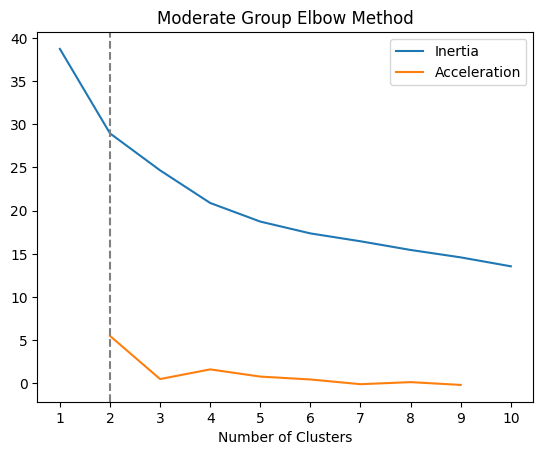

NameError: name 'silhouette_score' is not defined

In [ ]:
y_mod_kmeans = fit_kmeans(X_mod, 'Moderate')

plot_disc_y(X_mod_tsne_2, X_mod_tsne_3, y_mod_kmeans, "Moderate Group Clustering Using k-Means with Arithmetic Mean Features", *xyzlabels_tsne, [f'Cluster {unique}' for unique in np.unique(y_mod_kmeans)])  # == UPDATED ==

In [ ]:
# 1 cluster
clusters_mod_1 = assign_into_clusters(X_mod, Z_mod, 1)

# 3 clusters
clusters_mod_3 = assign_into_clusters(X_mod, Z_mod, 3)

# 5 clusters
clusters_mod_5 = assign_into_clusters(X_mod, Z_mod, 5)

# 7 clusters
clusters_mod_7 = assign_into_clusters(X_mod, Z_mod, 7)

NameError: name 'assign_into_clusters' is not defined

# Task 1

In [ ]:
sub_df = sub_df.reset_index()
sub_df

,index,DRUG,DOSAGE,FREQUENCY,group,V1-HAMD08,V1-HAMD09,DHAMD_norm,Drug Type,category
0,2,Duloxetine,60,1,moderate,0.25,0.25,4.750000,SNRI,both
1,6,Duloxetine,60,1,moderate,0.25,0.25,6.250000,SNRI,both
2,17,Duloxetine,60,1,moderate,0.00,0.00,1.916667,SNRI,neither
3,18,Duloxetine,60,1,moderate,0.50,0.00,4.666667,SNRI,retardation
4,19,Duloxetine,60,1,moderate,0.25,0.25,-0.500000,SNRI,both
...,...,...,...,...,...,...,...,...,...,...
727,1456,Fluoxetine,20,1,moderate,0.50,0.25,7.000000,SSRI,both
728,1458,Fluoxetine,20,1,moderate,0.25,0.00,3.500000,SSRI,retardation
729,1461,Fluoxetine,20,1,moderate,0.25,0.00,5.583333,SSRI,retardation
730,1462,Fluoxetine,20,1,moderate,0.25,0.00,2.250000,SSRI,retardation


In [ ]:
# within the participant 1, 3, 5, 7 clusters, separate the individuals into their respective clusters
def separate_clusters(original_arr, num_clusters):
    # input -> original_arr:         clusters_mod_n
    #          num_clusters:         n
    # output -> indices_array        2D array separating the clusters into sub arrays

    # initialize a 2D array to store indices
    indices_array = [[] for _ in range(num_clusters)]

    # Iterate through the original array and store indices
    for i, value in enumerate(original_arr):
        indices_array[value - 1].append(i)

    return indices_array

separated_1 = separate_clusters(clusters_mod_1, 1)
separated_3 = separate_clusters(clusters_mod_3, 3)
separated_5 = separate_clusters(clusters_mod_5, 5)
separated_7 = separate_clusters(clusters_mod_7, 7)

# get the statistical values for plotting a violin diagram [lowkey dont need this]
def calculate_statistics(DHAMD_scores):
    # input -> DHAMD_scores:        1d array []
    # output -> stats:              dictionary { 'name of stat' : value }
    stats = {
        'mean' : np.mean(DHAMD_scores),
        'std': np.std(DHAMD_scores),
        'min': np.min(DHAMD_scores),
        '25th_percentile': np.percentile(DHAMD_scores, 25),
        '50th_percentile': np.percentile(DHAMD_scores, 50),
        '75th_percentile': np.percentile(DHAMD_scores, 75),
        'max': np.max(DHAMD_scores)
    }
    return stats

# gather the DHAMD scores from the SSRI/SNRI categorization
def extract_DHAMD_scores(df, indices):
    # input -> df:                  pandas dataframe
    #          indices:             indices of different individuals in the n participant clusters
    # output -> DHAMD_SSRI:         dictionary of different clusters and arrays of all their DHAMD scores
    #          DHAMD_SNRI:          dictionary of different clusters and arrays of all their DHAMD scores

    # Initialize dictionaries for storing DHAMD values for each drug type
    DHAMD_SSRI = {}
    DHAMD_SNRI = {}

    # Iterate through the indices and separate values for 'SSRI' and 'SNRI'
    # for each of the sub arrays in the array of index arrays, create a [] containing all the DHAMD_norm values for
    # either the ones containing SSRI or SNRI
    for i, index_array in enumerate(indices):
        # Extract indices for current drug type
        SSRI_indices = [index for index in index_array if df.loc[index, 'Drug Type'] == 'SSRI']
        SNRI_indices = [index for index in index_array if df.loc[index, 'Drug Type'] == 'SNRI']

        # Extract normalized scores for current drug type
        DHAMD_SSRI[i+1] = df.loc[SSRI_indices, 'DHAMD_norm'].values.tolist()
        DHAMD_SNRI[i+1] = df.loc[SNRI_indices, 'DHAMD_norm'].values.tolist()

    return DHAMD_SSRI, DHAMD_SNRI

def compute_stats_for_each_drug_type(DHAMD_dict):
    # input -> DHAMD_dict:          either DHAMD_SSRI or DHAMD_SNRI
    # output -> stats_dict:         same format as DHAMD_dict but includes the stats for each cluster
    stats_dict = {}
    for key, scores in DHAMD_dict.items():
        if len(scores) == 0:
            return "Empty list"
        stats_dict[key] = calculate_statistics(scores)
    return stats_dict

# Calculate statistics
# 1 cluster
print("1 cluster stats:")
stats_SSRI_1, stats_SNRI_1 = extract_DHAMD_scores(sub_df, separated_1)
print(compute_stats_for_each_drug_type(stats_SSRI_1))
print(compute_stats_for_each_drug_type(stats_SNRI_1))
print("\n")

# 3 clusters
print("3 clusters stats:")
stats_SSRI_3, stats_SNRI_3 = extract_DHAMD_scores(sub_df, separated_3)
print(compute_stats_for_each_drug_type(stats_SSRI_3))
print(compute_stats_for_each_drug_type(stats_SNRI_3))
print("\n")

# 5 clusters
print("5 clusters stats:")
stats_SSRI_5, stats_SNRI_5 = extract_DHAMD_scores(sub_df, separated_5)
print(compute_stats_for_each_drug_type(stats_SSRI_5))
print(compute_stats_for_each_drug_type(stats_SNRI_5))
print("\n")

# 7 clusters
print("7 clusters stats:")
stats_SSRI_7, stats_SNRI_7 = extract_DHAMD_scores(sub_df, separated_7)
print(compute_stats_for_each_drug_type(stats_SSRI_7))
print(compute_stats_for_each_drug_type(stats_SNRI_7))
print("\n")

1 cluster stats:
{1: {'mean': 3.584375, 'std': 1.8977322792795204, 'min': -1.5, '25th_percentile': 2.5, '50th_percentile': 3.75, '75th_percentile': 5.0, 'max': 8.5}}
{1: {'mean': 3.5922202797202796, 'std': 1.9466730391038485, 'min': -2.666666666666666, '25th_percentile': 2.25, '50th_percentile': 3.75, '75th_percentile': 5.0, 'max': 8.5}}


3 clusters stats:
{1: {'mean': 3.4619565217391304, 'std': 1.9407518310199336, 'min': -1.5, '25th_percentile': 2.6250000000000004, '50th_percentile': 3.75, '75th_percentile': 4.729166666666667, 'max': 7.75}, 2: {'mean': 3.3741134751773045, 'std': 1.7268283848753838, 'min': -0.75, '25th_percentile': 2.25, '50th_percentile': 3.333333333333333, '75th_percentile': 4.5, 'max': 6.5}, 3: {'mean': 3.81592039800995, 'std': 1.9564356378221266, 'min': -0.75, '25th_percentile': 2.75, '50th_percentile': 3.833333333333333, '75th_percentile': 5.25, 'max': 8.5}}
{1: {'mean': 3.596311475409836, 'std': 1.8284217769491942, 'min': -1.75, '25th_percentile': 2.25, '50th_pe

In [ ]:
# goal is to returned combined dict to correctly represent the violin plots for ssri and snri next to each other
def combine_dicts(dict1, dict2):
    combined_dict = {}
    for cluster in dict1.keys():
        combined_dict[cluster] = {'SSRI': dict1[cluster], 'SNRI': dict2[cluster]}
    return combined_dict

combined_1 = combine_dicts(stats_SSRI_1, stats_SNRI_1)
combined_3 = combine_dicts(stats_SSRI_3, stats_SNRI_3)
combined_5 = combine_dicts(stats_SSRI_5, stats_SNRI_5)
combined_7 = combine_dicts(stats_SSRI_7, stats_SNRI_7)

Generating Violin Plots

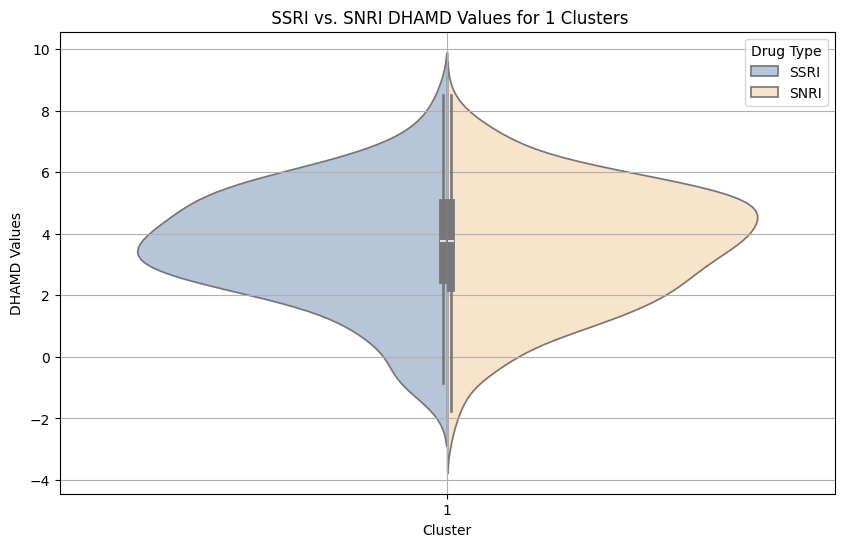

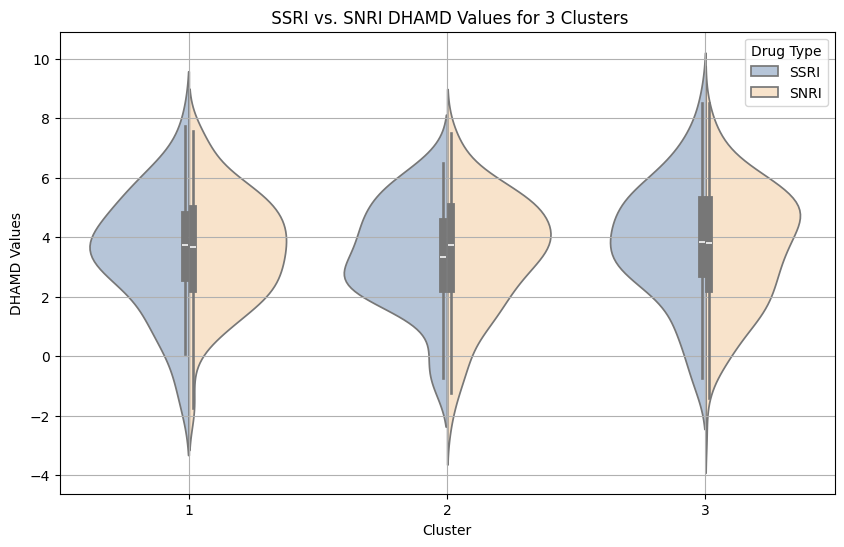

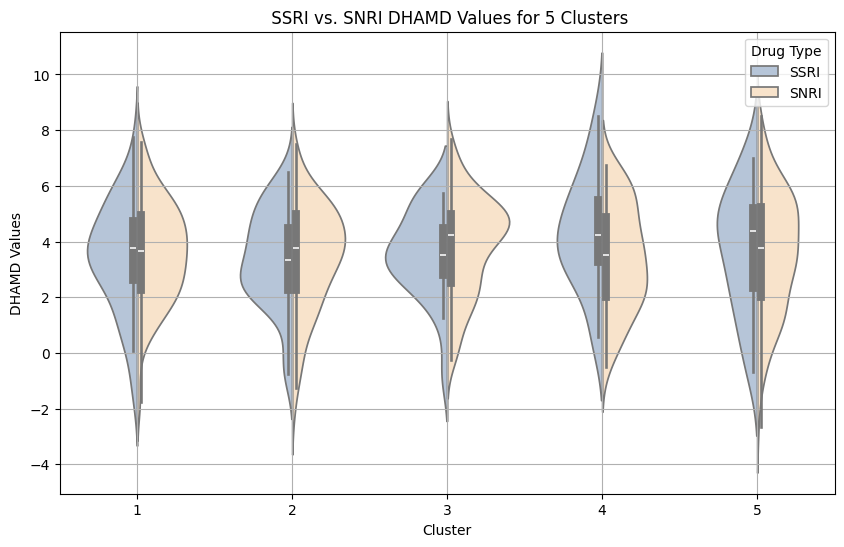

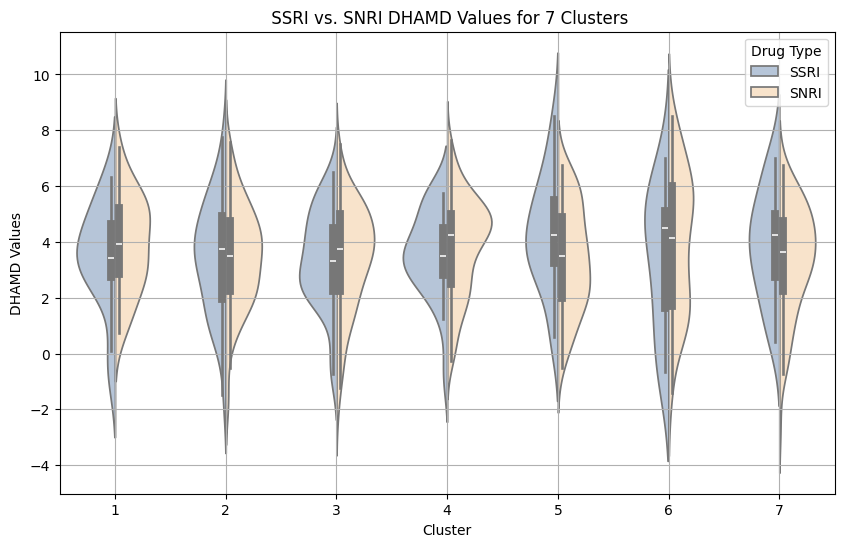

In [ ]:
def plot_violin(dose, dict_data, clusters, color_1, color_2):
    # Convert the combined dictionary to a DataFrame
    data = pd.DataFrame([(cluster, value, drug_type) for cluster, drugs in dict_data.items() for drug_type, values in drugs.items() for value in values], columns=['Cluster', 'Value', 'Drug Type'])

    # Plot violin plot using Seaborn
    plt.figure(figsize=(10, 6))
    sns.violinplot(data=data, x='Cluster', y='Value', hue='Drug Type', split=True, palette={'SSRI': color_1, 'SNRI': color_2})
    plt.xlabel('Cluster')
    plt.ylabel('DHAMD Values')
    plt.title(dose + ' SSRI vs. SNRI DHAMD Values for ' + str(clusters) + ' Clusters')
    plt.grid(True)
    plt.show()

plot_violin('', combined_1, 1, 'lightsteelblue', 'bisque')
plot_violin('', combined_3, 3, 'lightsteelblue', 'bisque')
plot_violin('', combined_5, 5, 'lightsteelblue', 'bisque')
plot_violin('', combined_7, 7, 'lightsteelblue', 'bisque')


For v1/v2 SSRI vs SNRI classification

In [ ]:
# reindex the dfs
sub_df2 = sub_df2.reset_index()
sub_df3 = sub_df3.reset_index()

In [ ]:
# remake clusters_mod_n since the indices are different for v1/v2 patients
clusters_mod_v1_1 = [clusters_mod_1[i - 1] for i in sub_df2.index if i <= len(clusters_mod_1)]
clusters_mod_v1_3 = [clusters_mod_3[i - 1] for i in sub_df2.index if i <= len(clusters_mod_3)]
clusters_mod_v1_5 = [clusters_mod_5[i - 1] for i in sub_df2.index if i <= len(clusters_mod_5)]
clusters_mod_v1_7 = [clusters_mod_7[i - 1] for i in sub_df2.index if i <= len(clusters_mod_7)]

clusters_mod_v2_1 = [clusters_mod_1[i - 1] for i in sub_df3.index if i <= len(clusters_mod_1)]
clusters_mod_v2_3 = [clusters_mod_3[i - 1] for i in sub_df3.index if i <= len(clusters_mod_3)]
clusters_mod_v2_5 = [clusters_mod_5[i - 1] for i in sub_df3.index if i <= len(clusters_mod_5)]
clusters_mod_v2_7 = [clusters_mod_7[i - 1] for i in sub_df3.index if i <= len(clusters_mod_7)]

{1: [5.0, 5.5, 5.25, -0.25, 3.25, 1.166666666666667, 2.0, 2.75, 1.0, 5.75, 1.25, 4.75, 1.25, 5.75, 4.0, 8.0, 4.0, 4.0, 1.5, 0.16666666666666696, 5.583333333333334, -2.666666666666666, 5.5, 0.0, 1.75, 1.75, 4.75, 4.0, 5.25, 7.75, 5.5, 3.0, 7.0, 1.75, 2.5, 2.5, 4.25, 3.75, 5.0, 3.5, 5.0, 5.75, 5.5, 5.0, 6.0, 6.25, 6.083333333333333, 4.75, 0.25, 2.25, 5.0, 4.75, 6.5, 4.75, 3.0, 5.25, 3.5, 2.0, 2.5, 7.666666666666667, 1.333333333333333, 0.75, 2.25, 2.25, 3.0, 1.75, 5.0, 4.75, 4.75, 5.0, 3.75, 5.5, 1.75, 2.25, 0.75, 0.75, 4.583333333333333, 1.5, 5.0, 2.5, 4.0, 2.0, 7.5, 4.5, 3.416666666666667, 6.25, 3.666666666666667, 7.0, 6.5, 3.0, 4.0, 2.75, 2.0, 3.75, 3.5, 1.25, 4.083333333333333, 6.0, 6.0, 2.0, 3.25, 5.5, 5.25, 7.0, 4.583333333333333, 5.333333333333333, -0.25, 1.75, 5.333333333333333, 1.5833333333333348, 2.75, 0.5, 5.833333333333333, 4.5, 4.5, 4.583333333333333, 5.0, -1.5, 5.25, 0.41666666666666696, 5.5, 3.0, 5.583333333333333, 6.25, 3.5, 3.5, 3.75, 3.25, 7.75, 2.583333333333334, 4.5, 5

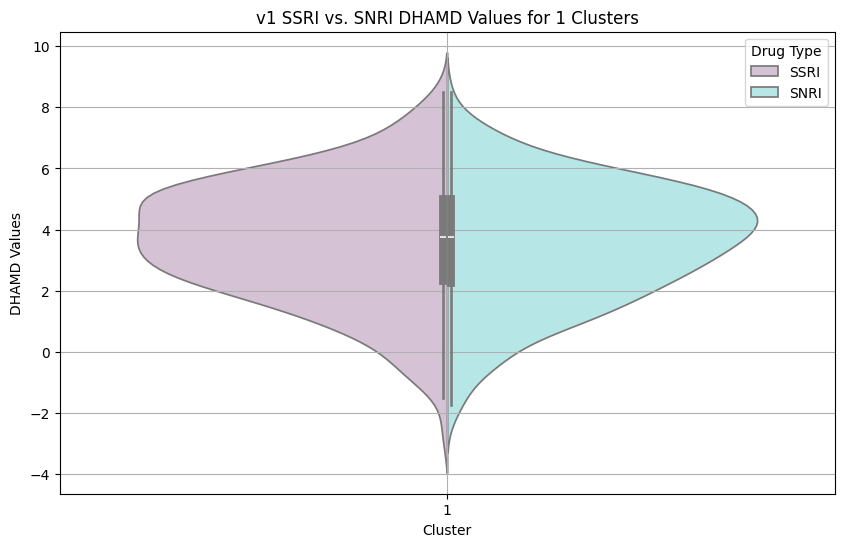

{1: [1.75, 4.75, 5.0, 5.5, 5.5, 5.25, 5.333333333333333, -0.25, 5.333333333333333, 1.5833333333333348, 5.25, 6.25, 3.5, 3.75, 3.25, 4.5, 4.0, 5.0, -0.75, 7.5, 2.25, 5.0, 4.25, 2.25, 4.75, 5.0, 4.666666666666667, 3.75, 3.833333333333333, 4.0, 4.416666666666667, -0.75, 1.75, 8.5, 3.75, 2.333333333333333, 2.75, 2.75, 2.7499999999999996, 0.5, 4.75, 1.25, 2.7499999999999996, 4.083333333333333, 2.5, 5.333333333333333, 3.75, 5.5, 5.5, 2.25, 3.75, 0.833333333333333, 2.75, 6.5], 2: [-0.25, 0.0, 4.75, 5.0, 4.75, 4.0, 2.75, 3.25, 1.75, 5.833333333333333, 4.5, 4.5, 4.583333333333333, 5.0, -1.5, 0.41666666666666696, 3.0, 3.5, 5.75, 4.0, 1.0, 1.0, 3.25, 5.75, 2.0, 4.083333333333333, 5.0, 5.25, 3.75, 3.0, 3.5, 2.583333333333333, -0.75, 3.75, 2.25, 3.25, 2.75, 0.08333333333333304, 3.75, 5.5, 3.2499999999999996, 3.333333333333333, 4.25, 4.25, 4.5, 5.5, 6.0, 4.5, 1.833333333333334, 3.833333333333333, 1.25, 2.583333333333334, 0.583333333333333, -0.833333333333333, 7.0, 5.583333333333333], 3: [5.0, 5.5, 5

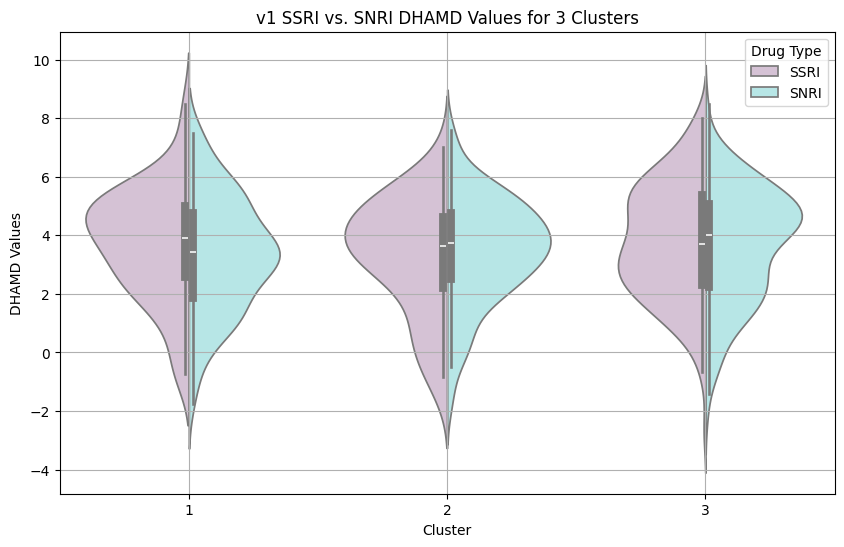

{1: [1.75, 4.75, 5.0, 5.5, 5.5, 5.25, 5.333333333333333, -0.25, 5.333333333333333, 1.5833333333333348, 5.25, 6.25, 3.5, 3.75, 3.25, 4.5, 4.0, 5.0, -0.75, 7.5, 2.25, 5.0, 4.25, 2.25, 4.75, 5.0, 4.666666666666667, 3.75, 3.833333333333333, 4.0, 4.416666666666667, -0.75, 1.75, 8.5, 3.75, 2.333333333333333, 2.75, 2.75, 2.7499999999999996, 0.5, 4.75, 1.25, 2.7499999999999996, 4.083333333333333, 2.5, 5.333333333333333, 3.75, 5.5, 5.5, 2.25, 3.75, 0.833333333333333, 2.75, 6.5], 2: [-0.25, 0.0, 4.75, 5.0, 4.75, 4.0, 2.75, 3.25, 1.75, 5.833333333333333, 4.5, 4.5, 4.583333333333333, 5.0, -1.5, 0.41666666666666696, 3.0, 3.5, 5.75, 4.0, 1.0, 1.0, 3.25, 5.75, 2.0, 4.083333333333333, 5.0, 5.25, 3.75, 3.0, 3.5, 2.583333333333333, -0.75, 3.75, 2.25, 3.25, 2.75, 0.08333333333333304, 3.75, 5.5, 3.2499999999999996, 3.333333333333333, 4.25, 4.25, 4.5, 5.5, 6.0, 4.5, 1.833333333333334, 3.833333333333333, 1.25, 2.583333333333334, 0.583333333333333, -0.833333333333333, 7.0, 5.583333333333333], 3: [5.0, 5.5, 3

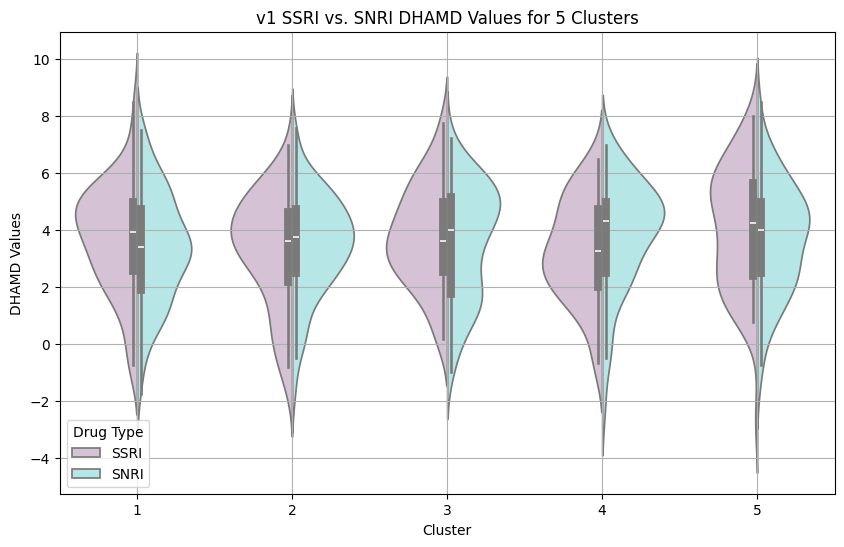

{1: [1.75, 6.25, 3.75, 4.5, 4.0, 5.0, -0.75, 4.0, 4.416666666666667, 1.75, 2.75, 0.5, 4.083333333333333, 5.333333333333333, 3.75, 6.5], 2: [4.75, 5.0, 5.5, 5.5, 5.25, 5.333333333333333, -0.25, 5.333333333333333, 1.5833333333333348, 5.25, 3.5, 3.25, 7.5, 2.25, 5.0, 4.25, 2.25, 4.75, 5.0, 4.666666666666667, 3.75, 3.833333333333333, -0.75, 8.5, 3.75, 2.333333333333333, 2.75, 2.7499999999999996, 4.75, 1.25, 2.7499999999999996, 2.5, 5.5, 5.5, 2.25, 3.75, 0.833333333333333, 2.75], 3: [-0.25, 0.0, 4.75, 5.0, 4.75, 4.0, 2.75, 3.25, 1.75, 5.833333333333333, 4.5, 4.5, 4.583333333333333, 5.0, -1.5, 0.41666666666666696, 3.0, 3.5, 5.75, 4.0, 1.0, 1.0, 3.25, 5.75, 2.0, 4.083333333333333, 5.0, 5.25, 3.75, 3.0, 3.5, 2.583333333333333, -0.75, 3.75, 2.25, 3.25, 2.75, 0.08333333333333304, 3.75, 5.5, 3.2499999999999996, 3.333333333333333, 4.25, 4.25, 4.5, 5.5, 6.0, 4.5, 1.833333333333334, 3.833333333333333, 1.25, 2.583333333333334, 0.583333333333333, -0.833333333333333, 7.0, 5.583333333333333], 4: [5.0, 5

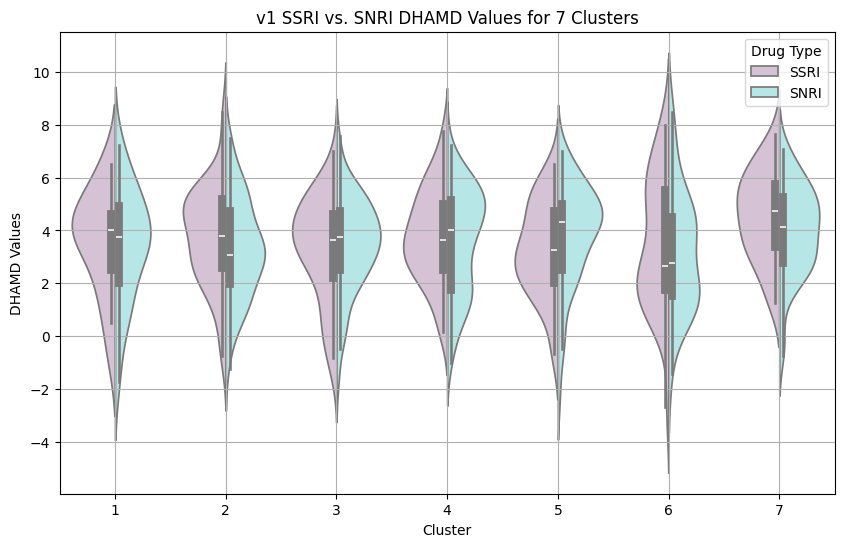

In [ ]:
# plot violin plots for each subset comparing v1/v2 'SSRI' vs 'SNRI' values
def plot_violin_for_frequency(df, frequency_value, original_cluster_arr, num_clusters, color_1, color_2):
    separated_clusters = separate_clusters(original_cluster_arr, num_clusters) # list of lists
    stats_SSRI, stats_SNRI = extract_DHAMD_scores(df, separated_clusters)
    print(stats_SSRI)
    print(stats_SNRI)

    # statistical numbers
    print(compute_stats_for_each_drug_type(stats_SSRI))
    print(compute_stats_for_each_drug_type(stats_SNRI))

    combined_dict = combine_dicts(stats_SSRI, stats_SNRI)
    plot_violin(frequency_value, combined_dict, num_clusters, color_1, color_2)


# Plot violin plots for v1
plot_violin_for_frequency(sub_df2, 'v1', clusters_mod_v1_1, 1, 'thistle', 'paleturquoise')
plot_violin_for_frequency(sub_df2, 'v1', clusters_mod_v1_3, 3, 'thistle', 'paleturquoise')
plot_violin_for_frequency(sub_df2, 'v1', clusters_mod_v1_5, 5, 'thistle', 'paleturquoise')
plot_violin_for_frequency(sub_df2, 'v1', clusters_mod_v1_7, 7, 'thistle', 'paleturquoise')

{1: [4.75, 6.25, 1.916666666666667, 4.666666666666667, -0.5, 2.25, 7.083333333333333, 1.0, -0.25, 4.25, 1.5, 4.250000000000001, 0.0, 4.5, 1.0, 1.083333333333334, 1.833333333333333, 1.5, 1.583333333333333, 3.833333333333333, 4.75, 2.5, 3.75, 5.833333333333333, 1.5, 3.416666666666667, -0.75, 2.916666666666667, 1.583333333333334, -0.25, -0.75, 2.25, 5.5, 2.25, 2.25, 1.0, 2.75, 5.0, 5.5, 1.25, -0.25, 3.0, -1.75, 1.5, 0.916666666666667, 1.25, 3.083333333333333, 4.25, 1.75, 3.25, 0.8333333333333339, 0.41666666666666696, 0.0, -1.75, 2.75, 1.5, 5.25, 0.25, 6.25, 5.0, 1.416666666666667, 5.5, 5.583333333333333, 8.0, 5.25, 1.25, -0.75, -0.25, 1.75, 3.25, 2.166666666666666, 1.166666666666667, 3.0, 5.75, 2.0, 2.75, 1.0, 2.25, 5.75, 6.0, 1.25, 3.0, 4.75, 1.25, 1.25, 2.5, 5.75, 4.0, 5.0, 8.0, 0.75, 6.5, 4.0, 4.0, 5.25, 1.5, 1.5, 1.666666666666667, 0.16666666666666696, 3.8333333333333335, 7.0, 5.583333333333334, -1.416666666666666, -2.666666666666666, 5.5, 3.75, 0.0, 1.75, 4.833333333333333, 1.75, 4.2

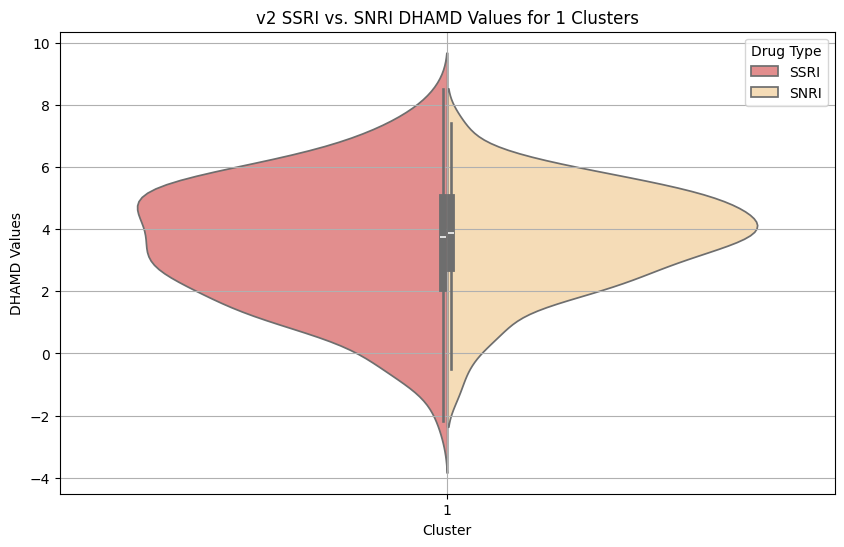

{1: [0.0, 1.0, 1.833333333333333, 2.5, -0.75, 1.583333333333334, -0.25, 1.0, 1.25, -1.75, 1.5, 0.916666666666667, 1.25, 3.083333333333333, 4.25, 3.25, 0.41666666666666696, 2.75, 1.5, 5.25, 3.75, 4.833333333333333, 1.75, 4.75, 6.25, 7.25, 5.0, 5.5, 1.0, 2.75, 2.75, 3.0, 5.5, 5.25, 5.583333333333334, 7.5, 6.25, 2.75, 5.25, 5.333333333333333, 3.75, 3.5, 1.583333333333334, 1.75, 2.083333333333334, 5.5, 4.5, 5.333333333333333, 5.75, 3.25, -0.25, 5.333333333333333, 1.5833333333333348, 2.75, 4.25, 1.0, 5.25, 6.666666666666667, 6.25, 3.5, 3.75, 3.25, 4.833333333333333, 6.916666666666667, 4.5, 2.0, 4.0, 5.0, 1.0, -0.75, 7.5, 2.25, 5.0, 4.25, 2.25, 4.75, 5.0, 4.666666666666667, 3.75, 3.833333333333333, 4.0, 4.416666666666667, -0.75, 1.75, 8.5, 3.75, 2.333333333333333, 2.75, 2.75, 2.7499999999999996, 0.5, 4.75, 1.25, 2.7499999999999996, 4.083333333333333, 2.5, 5.333333333333333, 3.75, 5.5, 5.5, 2.25, 3.75, 0.833333333333333, 2.75, 6.5], 2: [6.25, -0.5, 2.25, 7.083333333333333, 1.5, 3.833333333333

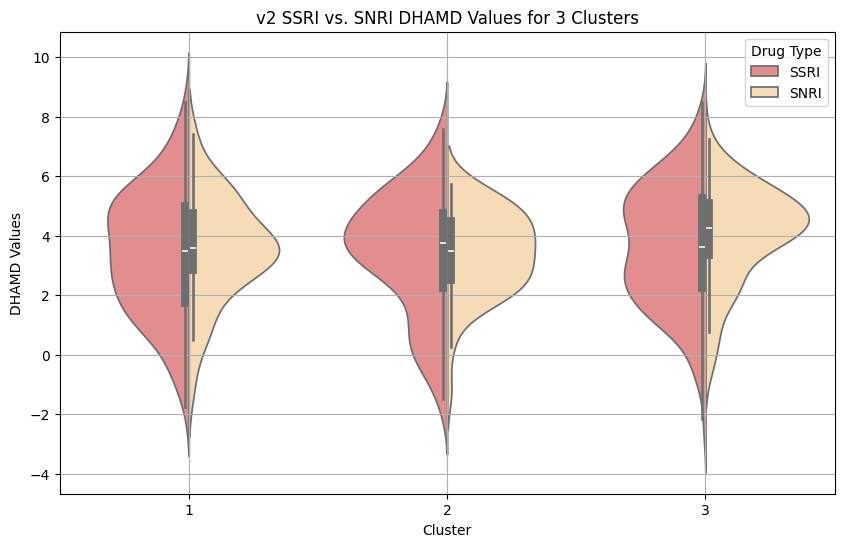

{1: [0.0, 1.0, 1.833333333333333, 2.5, -0.75, 1.583333333333334, -0.25, 1.0, 1.25, -1.75, 1.5, 0.916666666666667, 1.25, 3.083333333333333, 4.25, 3.25, 0.41666666666666696, 2.75, 1.5, 5.25, 3.75, 4.833333333333333, 1.75, 4.75, 6.25, 7.25, 5.0, 5.5, 1.0, 2.75, 2.75, 3.0, 5.5, 5.25, 5.583333333333334, 7.5, 6.25, 2.75, 5.25, 5.333333333333333, 3.75, 3.5, 1.583333333333334, 1.75, 2.083333333333334, 5.5, 4.5, 5.333333333333333, 5.75, 3.25, -0.25, 5.333333333333333, 1.5833333333333348, 2.75, 4.25, 1.0, 5.25, 6.666666666666667, 6.25, 3.5, 3.75, 3.25, 4.833333333333333, 6.916666666666667, 4.5, 2.0, 4.0, 5.0, 1.0, -0.75, 7.5, 2.25, 5.0, 4.25, 2.25, 4.75, 5.0, 4.666666666666667, 3.75, 3.833333333333333, 4.0, 4.416666666666667, -0.75, 1.75, 8.5, 3.75, 2.333333333333333, 2.75, 2.75, 2.7499999999999996, 0.5, 4.75, 1.25, 2.7499999999999996, 4.083333333333333, 2.5, 5.333333333333333, 3.75, 5.5, 5.5, 2.25, 3.75, 0.833333333333333, 2.75, 6.5], 2: [6.25, -0.5, 2.25, 7.083333333333333, 1.5, 3.833333333333

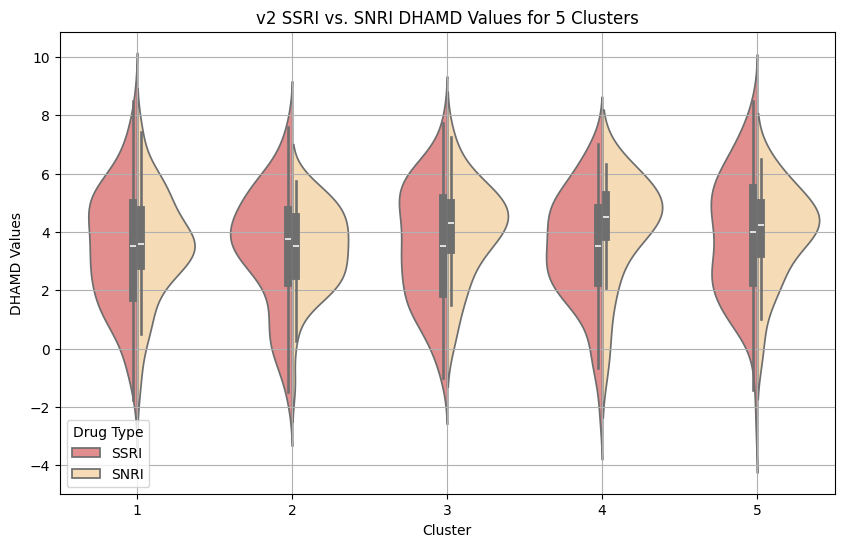

{1: [-0.75, 1.583333333333334, -1.75, 3.25, 1.75, 7.25, 3.25, 2.75, 4.25, 1.0, 6.25, 3.75, 6.916666666666667, 4.5, 4.0, 5.0, -0.75, 4.0, 4.416666666666667, 1.75, 2.75, 0.5, 4.083333333333333, 5.333333333333333, 3.75, 6.5], 2: [0.0, 1.0, 1.833333333333333, 2.5, -0.25, 1.0, 1.25, 1.5, 0.916666666666667, 1.25, 3.083333333333333, 4.25, 0.41666666666666696, 2.75, 1.5, 5.25, 3.75, 4.833333333333333, 4.75, 6.25, 5.0, 5.5, 1.0, 2.75, 2.75, 3.0, 5.5, 5.25, 5.583333333333334, 7.5, 6.25, 2.75, 5.25, 5.333333333333333, 3.75, 3.5, 1.583333333333334, 1.75, 2.083333333333334, 5.5, 4.5, 5.333333333333333, 5.75, -0.25, 5.333333333333333, 1.5833333333333348, 5.25, 6.666666666666667, 3.5, 3.25, 4.833333333333333, 2.0, 1.0, 7.5, 2.25, 5.0, 4.25, 2.25, 4.75, 5.0, 4.666666666666667, 3.75, 3.833333333333333, -0.75, 8.5, 3.75, 2.333333333333333, 2.75, 2.7499999999999996, 4.75, 1.25, 2.7499999999999996, 2.5, 5.5, 5.5, 2.25, 3.75, 0.833333333333333, 2.75], 3: [6.25, -0.5, 2.25, 7.083333333333333, 1.5, 3.8333333

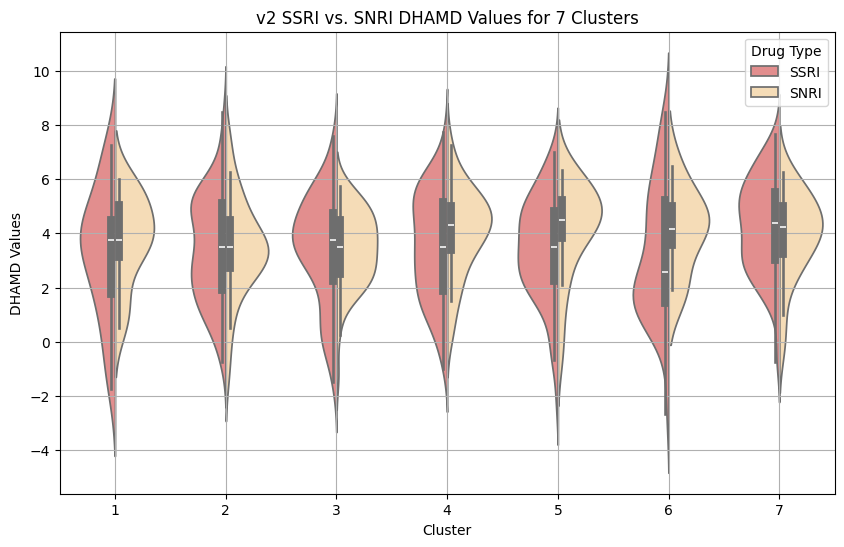

In [ ]:
# Plot violin plots for v2
plot_violin_for_frequency(sub_df3, 'v2', clusters_mod_v2_1, 1, 'lightcoral', 'navajowhite')
plot_violin_for_frequency(sub_df3, 'v2', clusters_mod_v2_3, 3, 'lightcoral', 'navajowhite')
plot_violin_for_frequency(sub_df3, 'v2', clusters_mod_v2_5, 5, 'lightcoral', 'navajowhite')
plot_violin_for_frequency(sub_df3, 'v2', clusters_mod_v2_7, 7, 'lightcoral', 'navajowhite')

In [ ]:
sub_df['Drug Type'].value_counts()

Drug Type
SNRI    572
SSRI    160
Name: count, dtype: int64

In [ ]:
sub_df2['Drug Type'].value_counts()

Drug Type
SNRI    468
SSRI    264
Name: count, dtype: int64

In [ ]:
sub_df3['Drug Type'].value_counts()

Drug Type
SSRI    526
SNRI    206
Name: count, dtype: int64

## Crosstab and Chi-Squared Test

Do a crosstab and chi-squared test for drug class vs. participant cluster. Plot the crosstab using a bar chart with the y-axis showing count, x-axis showing participant cluster, and hue showing drug class. Repeat for the three definitions of SSRI vs. SNRI.

### Crosstab for 3 drug categorizations

In [ ]:
# create a new feature in the dataframe called "cluster"
def crosstab_display(dataframe, cluster_arr):
    # input -> dataframe:          either sub_df or its variations (sub_df_v1, sub_df_v2) for different drug classes
    #          cluster_arr:        either clusters_mod_5 or its variations (clusters_mod_v1_5, clusters_mod_v2_5) for participant clustering
    # output ->
    dataframe['Cluster'] = cluster_arr

    return dataframe

sub_df = crosstab_display(sub_df, clusters_mod_5)
sub_df2 = crosstab_display(sub_df2, clusters_mod_v1_5)
sub_df3 = crosstab_display(sub_df3, clusters_mod_v2_5)

In [ ]:
# Creating the crosstab
crosstab = pd.crosstab(sub_df['Cluster'], sub_df['Drug Type'])
crosstab

Drug Type,SNRI,SSRI
Cluster,,
1,122,46
2,122,47
3,115,22
4,71,19
5,142,26


In [ ]:
crosstab_v1 = pd.crosstab(sub_df2['Cluster'], sub_df2['Drug Type'])
crosstab_v1

Drug Type,SNRI,SSRI
Cluster,,
1,114,54
2,113,56
3,87,50
4,53,37
5,101,67


In [ ]:
crosstab_v2 = pd.crosstab(sub_df3['Cluster'], sub_df3['Drug Type'])
crosstab_v2

Drug Type,SNRI,SSRI
Cluster,,
1,63,105
2,58,111
3,34,103
4,22,68
5,29,139


### Crosstab plotting

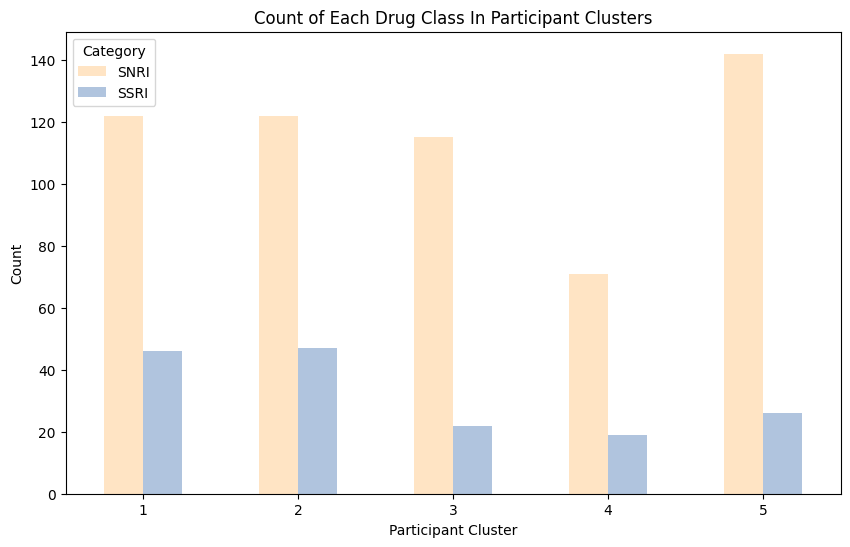

In [ ]:
# Plotting
crosstab.plot(kind='bar', stacked=False, color=['bisque', 'lightsteelblue'], figsize=(10, 6))

# Customizing the plot
plt.title('Count of Each Drug Class In Participant Clusters')
plt.xlabel('Participant Cluster')
plt.ylabel('Count')
plt.legend(title='Category')
plt.xticks(rotation=0)
plt.show()

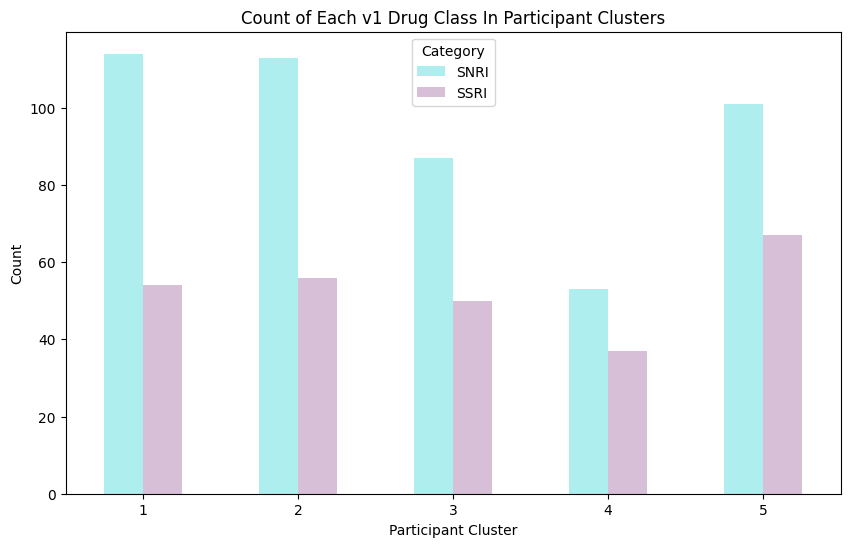

In [ ]:
# Plotting
crosstab_v1.plot(kind='bar', stacked=False, color=['paleturquoise', 'thistle'], figsize=(10, 6))

# Customizing the plot
plt.title('Count of Each v1 Drug Class In Participant Clusters')
plt.xlabel('Participant Cluster')
plt.ylabel('Count')
plt.legend(title='Category')
plt.xticks(rotation=0)
plt.show()

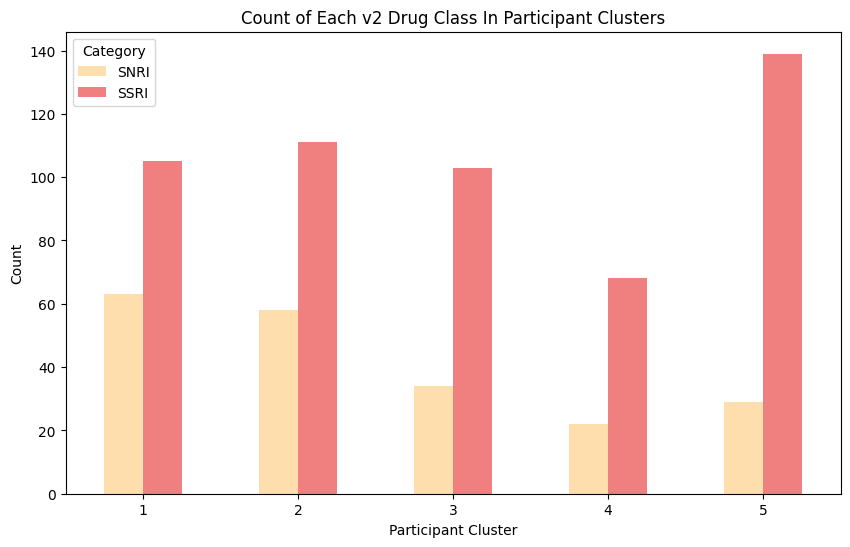

In [ ]:
# Plotting
crosstab_v2.plot(kind='bar', stacked=False, color=['navajowhite', 'lightcoral'], figsize=(10, 6))

# Customizing the plot
plt.title('Count of Each v2 Drug Class In Participant Clusters')
plt.xlabel('Participant Cluster')
plt.ylabel('Count')
plt.legend(title='Category')
plt.xticks(rotation=0)
plt.show()

### Chi-squared test

In [ ]:
import scipy.stats as stats

# Performing the Chi-squared test
chi2, p, dof, expected = stats.chi2_contingency(crosstab)

print("normal categorization ----------------------------")
print(f"Chi-squared statistic: {chi2}")
print(f"p-value: {p}")
print(f"Degrees of freedom: {dof}")
print("Expected frequencies:")
print(expected)
print("")

# v1 Chi-squared test
chi2, p, dof, expected = stats.chi2_contingency(crosstab_v1)

print("v1 ----------------------------")
print(f"Chi-squared statistic: {chi2}")
print(f"p-value: {p}")
print(f"Degrees of freedom: {dof}")
print("Expected frequencies:")
print(expected)
print("")

# v2 Chi-squared test
chi2, p, dof, expected = stats.chi2_contingency(crosstab_v2)

print("v2 ----------------------------")
print(f"Chi-squared statistic: {chi2}")
print(f"p-value: {p}")
print(f"Degrees of freedom: {dof}")
print("Expected frequencies:")
print(expected)

normal categorization ----------------------------
Chi-squared statistic: 13.239476664979733
p-value: 0.010163053883122046
Degrees of freedom: 4
Expected frequencies:
[[131.27868852  36.72131148]
 [132.06010929  36.93989071]
 [107.05464481  29.94535519]
 [ 70.32786885  19.67213115]
 [131.27868852  36.72131148]]

v1 ----------------------------
Chi-squared statistic: 3.815393311563893
p-value: 0.43156574542012305
Degrees of freedom: 4
Expected frequencies:
[[107.40983607  60.59016393]
 [108.04918033  60.95081967]
 [ 87.59016393  49.40983607]
 [ 57.54098361  32.45901639]
 [107.40983607  60.59016393]]

v2 ----------------------------
Chi-squared statistic: 21.655952364600196
p-value: 0.00023462816020294907
Degrees of freedom: 4
Expected frequencies:
[[ 47.27868852 120.72131148]
 [ 47.56010929 121.43989071]
 [ 38.55464481  98.44535519]
 [ 25.32786885  64.67213115]
 [ 47.27868852 120.72131148]]


# Task 2

In [ ]:
from collections import Counter
from pprint import pprint

pprint(dict(Counter(clusters_mod_1)))
pprint(dict(Counter(clusters_mod_3)))
pprint(dict(Counter(clusters_mod_5)))
pprint(dict(Counter(clusters_mod_7)))

{1: 732}
{1: 168, 2: 169, 3: 395}
{1: 168, 2: 169, 3: 137, 4: 90, 5: 168}
{1: 46, 2: 122, 3: 169, 4: 137, 5: 90, 6: 67, 7: 101}


In [ ]:
X = X_mod.copy()
X['cluster'] = clusters_mod_1
X['Age'] = df_moderate['AGE']
X['Sex'] = df_moderate['SEX']
X['Drug'] = sub_df['Drug Type']
X['DHAMD_norm'] = df_moderate['DHAMD_norm']
data = pd.get_dummies(X, columns=['Sex', 'Drug'], drop_first=True)
data = data.sort_values(by=['cluster'])

# Categorize Age into bins
age_bins = [18, 29, 49, 69, 89]
age_labels = ['18-29', '30-49', '50-69', '70-89']
data['Age Group'] = pd.cut(data['Age'], bins=age_bins, labels=age_labels, right=True)

# Create a sex column from Sex_M
data['Sex'] = data['Sex_M'].map({True: 'Male', False: 'Female'})
data.head()

,amean_0,amean_1,amean_2,amean_3,cluster,Age,DHAMD_norm,Sex_M,Drug_SSRI,Age Group,Sex
2,0.750,0.3750,0.3750,0.428571,1,71.759,4.75,True,False,70-89,Male
1032,0.625,0.0000,0.5625,0.571429,1,45.264,5.00,False,False,30-49,Female
1034,0.625,0.0000,0.5625,0.357143,1,42.143,2.75,False,False,30-49,Female
1035,0.500,0.1250,0.5000,0.642857,1,65.566,0.75,False,False,50-69,Female
1036,0.625,0.1875,0.5000,0.428571,1,49.500,-0.75,True,False,50-69,Male


In [ ]:
data['cluster'] = clusters_mod_3
data.head()

,amean_0,amean_1,amean_2,amean_3,cluster,Age,DHAMD_norm,Sex_M,Drug_SSRI,Age Group,Sex
2,0.750,0.3750,0.3750,0.428571,2,71.759,4.75,True,False,70-89,Male
1032,0.625,0.0000,0.5625,0.571429,3,45.264,5.00,False,False,30-49,Female
1034,0.625,0.0000,0.5625,0.357143,3,42.143,2.75,False,False,30-49,Female
1035,0.500,0.1250,0.5000,0.642857,2,65.566,0.75,False,False,50-69,Female
1036,0.625,0.1875,0.5000,0.428571,2,49.500,-0.75,True,False,50-69,Male


In [ ]:
from scipy.stats import chi2_contingency
# # Create cross-tabulations
# age_cluster_crosstab = pd.crosstab(data['Age Group'], data['cluster'])
# sex_cluster_crosstab = pd.crosstab(data['Sex'], data['cluster'])

# # Conduct chi-squared tests
# chi2_test_age = chi2_contingency(age_cluster_crosstab)
# chi2_test_sex = chi2_contingency(sex_cluster_crosstab)

# age_cluster_crosstab, chi2_test_age, sex_cluster_crosstab, chi2_test_sex

In [ ]:
def analyze_clusters(data, cluster_column):
    # Create cross-tabulations
    age_cluster_crosstab = pd.crosstab(data['Age Group'], data[cluster_column])
    sex_cluster_crosstab = pd.crosstab(data['Sex'], data[cluster_column])

    # Conduct chi-squared tests
    chi2_test_age = chi2_contingency(age_cluster_crosstab)
    chi2_test_sex = chi2_contingency(sex_cluster_crosstab)

    return age_cluster_crosstab, chi2_test_age, sex_cluster_crosstab, chi2_test_sex

In [ ]:
results = {}

# List of cluster models
cluster_models = {
    'clusters_mod_1': clusters_mod_1,
    'clusters_mod_3': clusters_mod_3,
    'clusters_mod_5': clusters_mod_5,
    'clusters_mod_7': clusters_mod_7
}

# Loop through each cluster model and analyze
for label, clusters in cluster_models.items():
    data['cluster'] = clusters
    age_crosstab, chi2_age, sex_crosstab, chi2_sex = analyze_clusters(data, 'cluster')
    results[label] = {
        'Age Crosstab': age_crosstab,
        'Chi2 Test Age': chi2_age,
        'Sex Crosstab': sex_crosstab,
        'Chi2 Test Sex': chi2_sex
    }

# Print or process results as needed
for label, result in results.items():
    print(f"Results for {label}:")
    print("Age Group Crosstab:\n", result['Age Crosstab'])
    print("Chi-Squared Test for Age Group:", result['Chi2 Test Age'][1])  # Showing p-value only for brevity
    print("Sex Crosstab:\n", result['Sex Crosstab'])
    print("Chi-Squared Test for Sex:", result['Chi2 Test Sex'][1])  # Showing p-value only
    print("\n")


Results for clusters_mod_1:
Age Group Crosstab:
 cluster      1
Age Group     
18-29       97
30-49      350
50-69      234
70-89       51
Chi-Squared Test for Age Group: 1.0
Sex Crosstab:
 cluster    1
Sex         
Female   499
Male     233
Chi-Squared Test for Sex: 1.0


Results for clusters_mod_3:
Age Group Crosstab:
 cluster     1   2    3
Age Group             
18-29      18  26   53
30-49      84  85  181
50-69      54  44  136
70-89      12  14   25
Chi-Squared Test for Age Group: 0.4950763625438207
Sex Crosstab:
 cluster    1    2    3
Sex                   
Female   120  114  265
Male      48   55  130
Chi-Squared Test for Sex: 0.5842847100092958


Results for clusters_mod_5:
Age Group Crosstab:
 cluster     1   2   3   4   5
Age Group                    
18-29      18  26  18   9  26
30-49      84  85  63  39  79
50-69      54  44  46  35  55
70-89      12  14  10   7   8
Chi-Squared Test for Age Group: 0.7296042272451855
Sex Crosstab:
 cluster    1    2   3   4    5
Sex     

# Task 3

In [ ]:
from collections import defaultdict

sub_df.index = df_mod_filtered.index

### 1 cluster

In [ ]:
fits_1 = defaultdict(dict)

In [ ]:
X1 = X_mod.copy()
X1['cluster'] = clusters_mod_1
X1['Age'] = df_moderate['AGE']
X1['Sex'] = df_moderate['SEX']
X1['Drug'] = sub_df['Drug Type']
X1['DHAMD_norm'] = df_moderate['DHAMD_norm']
encoded_X1 = pd.get_dummies(X1, columns=['Sex'], drop_first=True, dtype=float)
encoded_X1 = encoded_X1.sort_values(by=['cluster'])
encoded_X1

,amean_0,amean_1,amean_2,amean_3,cluster,Age,Drug,DHAMD_norm,Sex_M
2,0.750,0.375000,0.3750,0.428571,1,71.759,SNRI,4.750000,1.0
1032,0.625,0.000000,0.5625,0.571429,1,45.264,SSRI,5.000000,0.0
1034,0.625,0.000000,0.5625,0.357143,1,42.143,SSRI,2.750000,0.0
1035,0.500,0.125000,0.5000,0.642857,1,65.566,SNRI,0.750000,0.0
1036,0.625,0.187500,0.5000,0.428571,1,49.500,SSRI,-0.750000,1.0
...,...,...,...,...,...,...,...,...,...
416,0.750,0.125000,0.4375,0.500000,1,64.413,SNRI,7.000000,0.0
418,0.750,0.000000,0.6875,0.285714,1,53.133,SNRI,5.500000,0.0
421,0.750,0.250000,0.5625,0.214286,1,46.787,SNRI,5.250000,1.0
425,0.750,0.291667,0.4375,0.571429,1,53.486,SNRI,6.416667,0.0


In [ ]:
X_1_SSRI = encoded_X1[(encoded_X1['cluster'] == 1) &
                      (encoded_X1['Drug'] == 'SSRI')]
X_1_SNRI = encoded_X1[(encoded_X1['cluster'] == 1) &
                      (encoded_X1['Drug'] == 'SNRI')]

In [ ]:
import statsmodels.api as sm
y_mod = X_1_SSRI['DHAMD_norm']
x_mod = X_1_SSRI.drop(['DHAMD_norm', 'Drug', 'cluster'], axis=1)

x_mod = sm.add_constant(x_mod)
result = sm.OLS(y_mod, x_mod).fit()
print(result.summary())

fits_1[1]['SSRI'] = result

                            OLS Regression Results                            
Dep. Variable:             DHAMD_norm   R-squared:                       0.094
Model:                            OLS   Adj. R-squared:                  0.058
Method:                 Least Squares   F-statistic:                     2.636
Date:                Sun, 28 Apr 2024   Prob (F-statistic):             0.0184
Time:                        23:13:08   Log-Likelihood:                -321.66
No. Observations:                 160   AIC:                             657.3
Df Residuals:                     153   BIC:                             678.9
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.3598      1.539     -1.534      0.1

In [ ]:
y_mod = X_1_SNRI['DHAMD_norm']
x_mod = X_1_SNRI.drop(['DHAMD_norm', 'Drug', 'cluster'], axis=1)

x_mod = sm.add_constant(x_mod)
result = sm.OLS(y_mod, x_mod).fit()
print(result.summary())

fits_1[1]['SNRI'] = result

                            OLS Regression Results                            
Dep. Variable:             DHAMD_norm   R-squared:                       0.080
Model:                            OLS   Adj. R-squared:                  0.070
Method:                 Least Squares   F-statistic:                     8.139
Date:                Sun, 28 Apr 2024   Prob (F-statistic):           1.87e-08
Time:                        23:13:08   Log-Likelihood:                -1168.9
No. Observations:                 572   AIC:                             2352.
Df Residuals:                     565   BIC:                             2382.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6335      0.865      0.732      0.4

### 3 clusters

In [ ]:
fits_3 = defaultdict(dict)

In [ ]:
X3 = X_mod.copy()
X3['cluster'] = clusters_mod_3
X3['Age'] = df_moderate['AGE']
X3['Sex'] = df_moderate['SEX']
X3['Drug'] = sub_df['Drug Type']
X3['DHAMD_norm'] = df_moderate['DHAMD_norm']
encoded_X3 = pd.get_dummies(X3, columns=['Sex'], drop_first=True, dtype=float)
encoded_X3 = encoded_X3.sort_values(by=['cluster'])
encoded_X3

,amean_0,amean_1,amean_2,amean_3,cluster,Age,Drug,DHAMD_norm,Sex_M
1139,0.375,0.395833,0.4375,0.464286,1,57.232,SNRI,2.583333,0.0
1052,0.500,0.333333,0.3125,0.428571,1,40.939,SNRI,5.333333,0.0
1049,0.500,0.416667,0.4375,0.357143,1,65.103,SNRI,5.083333,0.0
1047,0.500,0.333333,0.5625,0.357143,1,47.197,SSRI,6.333333,0.0
1040,0.500,0.187500,0.3750,0.392857,1,45.809,SNRI,3.250000,0.0
...,...,...,...,...,...,...,...,...,...
966,0.625,0.187500,0.5625,0.357143,3,59.269,SSRI,2.750000,0.0
965,0.625,0.416667,0.4375,0.321429,3,35.471,SNRI,3.666667,0.0
346,0.750,0.062500,0.5625,0.392857,3,62.439,SNRI,0.750000,1.0
340,0.750,0.208333,0.5625,0.500000,3,59.011,SNRI,4.583333,0.0


In [ ]:
X3_1_SSRI = encoded_X3[(encoded_X3['cluster'] == 1) &
                      (encoded_X3['Drug'] == 'SSRI')]
X3_1_SNRI = encoded_X3[(encoded_X3['cluster'] == 1) &
                      (encoded_X3['Drug'] == 'SNRI')]

X3_2_SSRI = encoded_X3[(encoded_X3['cluster'] == 2) &
                      (encoded_X3['Drug'] == 'SSRI')]
X3_2_SNRI = encoded_X3[(encoded_X3['cluster'] == 2) &
                      (encoded_X3['Drug'] == 'SNRI')]

X3_3_SSRI = encoded_X3[(encoded_X3['cluster'] == 3) &
                      (encoded_X3['Drug'] == 'SSRI')]
X3_3_SNRI = encoded_X3[(encoded_X3['cluster'] == 3) &
                      (encoded_X3['Drug'] == 'SNRI')]

In [ ]:
y_mod = X3_1_SSRI['DHAMD_norm']
x_mod = X3_1_SSRI.drop(['DHAMD_norm', 'Drug', 'cluster'], axis=1)

x_mod = sm.add_constant(x_mod)
result = sm.OLS(y_mod, x_mod).fit()
print(result.summary())

fits_3[1]['SSRI'] = result

                            OLS Regression Results                            
Dep. Variable:             DHAMD_norm   R-squared:                       0.280
Model:                            OLS   Adj. R-squared:                  0.169
Method:                 Least Squares   F-statistic:                     2.529
Date:                Sun, 28 Apr 2024   Prob (F-statistic):             0.0365
Time:                        23:13:08   Log-Likelihood:                -88.215
No. Observations:                  46   AIC:                             190.4
Df Residuals:                      39   BIC:                             203.2
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.8811      2.900     -2.028      0.0

In [ ]:
y_mod = X3_1_SNRI['DHAMD_norm']
x_mod = X3_1_SNRI.drop(['DHAMD_norm', 'Drug', 'cluster'], axis=1)

x_mod = sm.add_constant(x_mod)
result = sm.OLS(y_mod, x_mod).fit()
print(result.summary())

fits_3[1]['SNRI'] = result

                            OLS Regression Results                            
Dep. Variable:             DHAMD_norm   R-squared:                       0.151
Model:                            OLS   Adj. R-squared:                  0.107
Method:                 Least Squares   F-statistic:                     3.411
Date:                Sun, 28 Apr 2024   Prob (F-statistic):            0.00391
Time:                        23:13:08   Log-Likelihood:                -236.74
No. Observations:                 122   AIC:                             487.5
Df Residuals:                     115   BIC:                             507.1
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.8624      1.806      1.031      0.3

In [ ]:
y_mod = X3_2_SSRI['DHAMD_norm']
x_mod = X3_2_SSRI.drop(['DHAMD_norm', 'Drug', 'cluster'], axis=1)

x_mod = sm.add_constant(x_mod)
result = sm.OLS(y_mod, x_mod).fit()
print(result.summary())

fits_3[2]['SSRI'] = result

                            OLS Regression Results                            
Dep. Variable:             DHAMD_norm   R-squared:                       0.108
Model:                            OLS   Adj. R-squared:                 -0.025
Method:                 Least Squares   F-statistic:                    0.8097
Date:                Sun, 28 Apr 2024   Prob (F-statistic):              0.569
Time:                        23:13:08   Log-Likelihood:                -89.672
No. Observations:                  47   AIC:                             193.3
Df Residuals:                      40   BIC:                             206.3
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.1706      3.230      0.672      0.5

In [ ]:
y_mod = X3_2_SNRI['DHAMD_norm']
x_mod = X3_2_SNRI.drop(['DHAMD_norm', 'Drug', 'cluster'], axis=1)

x_mod = sm.add_constant(x_mod)
result = sm.OLS(y_mod, x_mod).fit()
print(result.summary())

fits_3[2]['SNRI'] = result

                            OLS Regression Results                            
Dep. Variable:             DHAMD_norm   R-squared:                       0.053
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.072
Date:                Sun, 28 Apr 2024   Prob (F-statistic):              0.383
Time:                        23:13:08   Log-Likelihood:                -249.59
No. Observations:                 122   AIC:                             513.2
Df Residuals:                     115   BIC:                             532.8
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.5090      2.402     -0.628      0.5

In [ ]:
y_mod = X3_3_SSRI['DHAMD_norm']
x_mod = X3_3_SSRI.drop(['DHAMD_norm', 'Drug', 'cluster'], axis=1)

x_mod = sm.add_constant(x_mod)
result = sm.OLS(y_mod, x_mod).fit()
print(result.summary())

fits_3[3]['SSRI'] = result

                            OLS Regression Results                            
Dep. Variable:             DHAMD_norm   R-squared:                       0.160
Model:                            OLS   Adj. R-squared:                  0.076
Method:                 Least Squares   F-statistic:                     1.899
Date:                Sun, 28 Apr 2024   Prob (F-statistic):             0.0957
Time:                        23:13:08   Log-Likelihood:                -134.21
No. Observations:                  67   AIC:                             282.4
Df Residuals:                      60   BIC:                             297.9
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.2311      2.845     -0.433      0.6

In [ ]:
y_mod = X3_3_SNRI['DHAMD_norm']
x_mod = X3_3_SNRI.drop(['DHAMD_norm', 'Drug', 'cluster'], axis=1)

x_mod = sm.add_constant(x_mod)
result = sm.OLS(y_mod, x_mod).fit()
print(result.summary())

fits_3[3]['SNRI'] = result

                            OLS Regression Results                            
Dep. Variable:             DHAMD_norm   R-squared:                       0.086
Model:                            OLS   Adj. R-squared:                  0.069
Method:                 Least Squares   F-statistic:                     5.011
Date:                Sun, 28 Apr 2024   Prob (F-statistic):           6.31e-05
Time:                        23:13:08   Log-Likelihood:                -677.04
No. Observations:                 328   AIC:                             1368.
Df Residuals:                     321   BIC:                             1395.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.2130      1.329      0.913      0.3

### 5 clusters

In [ ]:
fits_5 = defaultdict(dict)

In [ ]:
X5 = X_mod.copy()
X5['cluster'] = clusters_mod_5
X5['Age'] = df_moderate['AGE']
X5['Sex'] = df_moderate['SEX']
X5['Drug'] = sub_df['Drug Type']
X5['DHAMD_norm'] = df_moderate['DHAMD_norm']
encoded_X5 = pd.get_dummies(X5, columns=['Sex'], drop_first=True, dtype=float)
encoded_X5 = encoded_X5.sort_values(by=['cluster'])
encoded_X5

,amean_0,amean_1,amean_2,amean_3,cluster,Age,Drug,DHAMD_norm,Sex_M
1139,0.375,0.395833,0.4375,0.464286,1,57.232,SNRI,2.583333,0.0
1052,0.500,0.333333,0.3125,0.428571,1,40.939,SNRI,5.333333,0.0
1049,0.500,0.416667,0.4375,0.357143,1,65.103,SNRI,5.083333,0.0
1047,0.500,0.333333,0.5625,0.357143,1,47.197,SSRI,6.333333,0.0
1040,0.500,0.187500,0.3750,0.392857,1,45.809,SNRI,3.250000,0.0
...,...,...,...,...,...,...,...,...,...
1259,0.750,0.000000,0.4375,0.464286,5,47.920,SNRI,4.250000,0.0
202,0.750,0.187500,0.5625,0.535714,5,56.695,SNRI,1.250000,0.0
306,0.750,0.000000,0.4375,0.357143,5,43.759,SNRI,2.000000,1.0
211,0.750,0.125000,0.5625,0.607143,5,57.078,SNRI,8.000000,0.0


In [ ]:
X5_1_SSRI = encoded_X5[(encoded_X5['cluster'] == 1) &
                      (encoded_X5['Drug'] == 'SSRI')]
X5_1_SNRI = encoded_X5[(encoded_X5['cluster'] == 1) &
                      (encoded_X5['Drug'] == 'SNRI')]

X5_2_SSRI = encoded_X5[(encoded_X5['cluster'] == 2) &
                      (encoded_X5['Drug'] == 'SSRI')]
X5_2_SNRI = encoded_X5[(encoded_X5['cluster'] == 2) &
                      (encoded_X5['Drug'] == 'SNRI')]

X5_3_SSRI = encoded_X5[(encoded_X5['cluster'] == 3) &
                      (encoded_X5['Drug'] == 'SSRI')]
X5_3_SNRI = encoded_X5[(encoded_X5['cluster'] == 3) &
                      (encoded_X5['Drug'] == 'SNRI')]

X5_4_SSRI = encoded_X5[(encoded_X5['cluster'] == 4) &
                      (encoded_X5['Drug'] == 'SSRI')]
X5_4_SNRI = encoded_X5[(encoded_X5['cluster'] == 4) &
                      (encoded_X5['Drug'] == 'SNRI')]

X5_5_SSRI = encoded_X5[(encoded_X5['cluster'] == 5) &
                      (encoded_X5['Drug'] == 'SSRI')]
X5_5_SNRI = encoded_X5[(encoded_X5['cluster'] == 5) &
                      (encoded_X5['Drug'] == 'SNRI')]

In [ ]:
y_mod = X5_1_SSRI['DHAMD_norm']
x_mod = X5_1_SSRI.drop(['DHAMD_norm', 'Drug', 'cluster'], axis=1)

x_mod = sm.add_constant(x_mod)
result = sm.OLS(y_mod, x_mod).fit()
print(result.summary())

fits_5[1]['SSRI'] = result

                            OLS Regression Results                            
Dep. Variable:             DHAMD_norm   R-squared:                       0.280
Model:                            OLS   Adj. R-squared:                  0.169
Method:                 Least Squares   F-statistic:                     2.529
Date:                Sun, 28 Apr 2024   Prob (F-statistic):             0.0365
Time:                        23:13:08   Log-Likelihood:                -88.215
No. Observations:                  46   AIC:                             190.4
Df Residuals:                      39   BIC:                             203.2
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.8811      2.900     -2.028      0.0

In [ ]:
y_mod = X5_1_SNRI['DHAMD_norm']
x_mod = X5_1_SNRI.drop(['DHAMD_norm', 'Drug', 'cluster'], axis=1)

x_mod = sm.add_constant(x_mod)
result = sm.OLS(y_mod, x_mod).fit()
print(result.summary())

fits_5[1]['SNRI'] = result

                            OLS Regression Results                            
Dep. Variable:             DHAMD_norm   R-squared:                       0.151
Model:                            OLS   Adj. R-squared:                  0.107
Method:                 Least Squares   F-statistic:                     3.411
Date:                Sun, 28 Apr 2024   Prob (F-statistic):            0.00391
Time:                        23:13:08   Log-Likelihood:                -236.74
No. Observations:                 122   AIC:                             487.5
Df Residuals:                     115   BIC:                             507.1
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.8624      1.806      1.031      0.3

In [ ]:
y_mod = X5_2_SSRI['DHAMD_norm']
x_mod = X5_2_SSRI.drop(['DHAMD_norm', 'Drug', 'cluster'], axis=1)

x_mod = sm.add_constant(x_mod)
result = sm.OLS(y_mod, x_mod).fit()
print(result.summary())

fits_5[2]['SSRI'] = result

                            OLS Regression Results                            
Dep. Variable:             DHAMD_norm   R-squared:                       0.108
Model:                            OLS   Adj. R-squared:                 -0.025
Method:                 Least Squares   F-statistic:                    0.8097
Date:                Sun, 28 Apr 2024   Prob (F-statistic):              0.569
Time:                        23:13:08   Log-Likelihood:                -89.672
No. Observations:                  47   AIC:                             193.3
Df Residuals:                      40   BIC:                             206.3
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.1706      3.230      0.672      0.5

In [ ]:
y_mod = X5_2_SNRI['DHAMD_norm']
x_mod = X5_2_SNRI.drop(['DHAMD_norm', 'Drug', 'cluster'], axis=1)

x_mod = sm.add_constant(x_mod)
result = sm.OLS(y_mod, x_mod).fit()
print(result.summary())

fits_5[2]['SNRI'] = result

                            OLS Regression Results                            
Dep. Variable:             DHAMD_norm   R-squared:                       0.053
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.072
Date:                Sun, 28 Apr 2024   Prob (F-statistic):              0.383
Time:                        23:13:08   Log-Likelihood:                -249.59
No. Observations:                 122   AIC:                             513.2
Df Residuals:                     115   BIC:                             532.8
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.5090      2.402     -0.628      0.5

In [ ]:
y_mod = X5_3_SSRI['DHAMD_norm']
x_mod = X5_3_SSRI.drop(['DHAMD_norm', 'Drug', 'cluster'], axis=1)

x_mod = sm.add_constant(x_mod)
result = sm.OLS(y_mod, x_mod).fit()
print(result.summary())

fits_5[3]['SSRI'] = result

                            OLS Regression Results                            
Dep. Variable:             DHAMD_norm   R-squared:                       0.353
Model:                            OLS   Adj. R-squared:                  0.094
Method:                 Least Squares   F-statistic:                     1.365
Date:                Sun, 28 Apr 2024   Prob (F-statistic):              0.291
Time:                        23:13:09   Log-Likelihood:                -35.837
No. Observations:                  22   AIC:                             85.67
Df Residuals:                      15   BIC:                             93.31
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5307      6.131      0.087      0.9

In [ ]:
y_mod = X5_3_SNRI['DHAMD_norm']
x_mod = X5_3_SNRI.drop(['DHAMD_norm', 'Drug', 'cluster'], axis=1)

x_mod = sm.add_constant(x_mod)
result = sm.OLS(y_mod, x_mod).fit()
print(result.summary())

fits_5[3]['SNRI'] = result

                            OLS Regression Results                            
Dep. Variable:             DHAMD_norm   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.107
Method:                 Least Squares   F-statistic:                     3.279
Date:                Sun, 28 Apr 2024   Prob (F-statistic):            0.00531
Time:                        23:13:09   Log-Likelihood:                -219.23
No. Observations:                 115   AIC:                             452.5
Df Residuals:                     108   BIC:                             471.7
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2356      2.098      0.112      0.9

In [ ]:
y_mod = X5_4_SSRI['DHAMD_norm']
x_mod = X5_4_SSRI.drop(['DHAMD_norm', 'Drug', 'cluster'], axis=1)

x_mod = sm.add_constant(x_mod)
result = sm.OLS(y_mod, x_mod).fit()
print(result.summary())

fits_5[4]['SSRI'] = result

                            OLS Regression Results                            
Dep. Variable:             DHAMD_norm   R-squared:                       0.546
Model:                            OLS   Adj. R-squared:                  0.319
Method:                 Least Squares   F-statistic:                     2.407
Date:                Sun, 28 Apr 2024   Prob (F-statistic):             0.0921
Time:                        23:13:09   Log-Likelihood:                -32.609
No. Observations:                  19   AIC:                             79.22
Df Residuals:                      12   BIC:                             85.83
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4507      5.104     -0.088      0.9

/usr/local/lib/python3.10/dist-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=19
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


In [ ]:
y_mod = X5_4_SNRI['DHAMD_norm']
x_mod = X5_4_SNRI.drop(['DHAMD_norm', 'Drug', 'cluster'], axis=1)

x_mod = sm.add_constant(x_mod)
result = sm.OLS(y_mod, x_mod).fit()
print(result.summary())

fits_5[4]['SNRI'] = result

                            OLS Regression Results                            
Dep. Variable:             DHAMD_norm   R-squared:                       0.212
Model:                            OLS   Adj. R-squared:                  0.138
Method:                 Least Squares   F-statistic:                     2.864
Date:                Sun, 28 Apr 2024   Prob (F-statistic):             0.0156
Time:                        23:13:09   Log-Likelihood:                -136.89
No. Observations:                  71   AIC:                             287.8
Df Residuals:                      64   BIC:                             303.6
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.4878      2.820      0.528      0.6

In [ ]:
y_mod = X5_5_SSRI['DHAMD_norm']
x_mod = X5_5_SSRI.drop(['DHAMD_norm', 'Drug', 'cluster'], axis=1)

x_mod = sm.add_constant(x_mod)
result = sm.OLS(y_mod, x_mod).fit()
print(result.summary())

fits_5[5]['SSRI'] = result

                            OLS Regression Results                            
Dep. Variable:             DHAMD_norm   R-squared:                       0.082
Model:                            OLS   Adj. R-squared:                 -0.208
Method:                 Least Squares   F-statistic:                    0.2817
Date:                Sun, 28 Apr 2024   Prob (F-statistic):              0.939
Time:                        23:13:09   Log-Likelihood:                -55.843
No. Observations:                  26   AIC:                             125.7
Df Residuals:                      19   BIC:                             134.5
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4022     10.152      0.040      0.9

In [ ]:
y_mod = X5_5_SNRI['DHAMD_norm']
x_mod = X5_5_SNRI.drop(['DHAMD_norm', 'Drug', 'cluster'], axis=1)

x_mod = sm.add_constant(x_mod)
result = sm.OLS(y_mod, x_mod).fit()
print(result.summary())

fits_5[5]['SNRI'] = result

                            OLS Regression Results                            
Dep. Variable:             DHAMD_norm   R-squared:                       0.057
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     1.371
Date:                Sun, 28 Apr 2024   Prob (F-statistic):              0.231
Time:                        23:13:09   Log-Likelihood:                -308.83
No. Observations:                 142   AIC:                             631.7
Df Residuals:                     135   BIC:                             652.4
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4677      4.644      0.101      0.9

### 7 clusters

In [ ]:
fits_7 = defaultdict(dict)

In [ ]:
X7 = X_mod.copy()
X7['cluster'] = clusters_mod_7
X7['Age'] = df_moderate['AGE']
X7['Sex'] = df_moderate['SEX']
X7['Drug'] = sub_df['Drug Type']
X7['DHAMD_norm'] = df_moderate['DHAMD_norm']
encoded_X7 = pd.get_dummies(X7, columns=['Sex'], drop_first=True, dtype=float)
encoded_X7 = encoded_X7.sort_values(by=['cluster'])
encoded_X7

,amean_0,amean_1,amean_2,amean_3,cluster,Age,Drug,DHAMD_norm,Sex_M
1139,0.375,0.395833,0.4375,0.464286,1,57.232000,SNRI,2.583333,0.0
772,0.250,0.270833,0.4375,0.535714,1,22.789870,SNRI,5.583333,0.0
780,0.500,0.354167,0.3750,0.392857,1,24.991102,SSRI,2.583333,0.0
106,0.375,0.375000,0.3750,0.321429,1,73.204000,SNRI,3.000000,1.0
835,0.500,0.312500,0.3125,0.464286,1,49.215606,SSRI,3.250000,0.0
...,...,...,...,...,...,...,...,...,...
442,0.750,0.000000,0.6250,0.392857,7,41.322000,SNRI,6.750000,0.0
1272,0.750,0.000000,0.5625,0.392857,7,60.922000,SNRI,5.000000,0.0
197,0.750,0.000000,0.6250,0.428571,7,69.607000,SNRI,5.750000,0.0
441,0.750,0.062500,0.4375,0.357143,7,35.055000,SNRI,4.000000,0.0


In [ ]:
X7_1_SSRI = encoded_X7[(encoded_X7['cluster'] == 1) &
                      (encoded_X7['Drug'] == 'SSRI')]
X7_1_SNRI = encoded_X7[(encoded_X7['cluster'] == 1) &
                      (encoded_X7['Drug'] == 'SNRI')]

X7_2_SSRI = encoded_X7[(encoded_X7['cluster'] == 2) &
                      (encoded_X7['Drug'] == 'SSRI')]
X7_2_SNRI = encoded_X7[(encoded_X7['cluster'] == 2) &
                      (encoded_X7['Drug'] == 'SNRI')]

X7_3_SSRI = encoded_X7[(encoded_X7['cluster'] == 3) &
                      (encoded_X7['Drug'] == 'SSRI')]
X7_3_SNRI = encoded_X7[(encoded_X7['cluster'] == 3) &
                      (encoded_X7['Drug'] == 'SNRI')]

X7_4_SSRI = encoded_X7[(encoded_X7['cluster'] == 4) &
                      (encoded_X7['Drug'] == 'SSRI')]
X7_4_SNRI = encoded_X7[(encoded_X7['cluster'] == 4) &
                      (encoded_X7['Drug'] == 'SNRI')]

X7_5_SSRI = encoded_X7[(encoded_X7['cluster'] == 5) &
                      (encoded_X7['Drug'] == 'SSRI')]
X7_5_SNRI = encoded_X7[(encoded_X7['cluster'] == 5) &
                      (encoded_X7['Drug'] == 'SNRI')]

X7_6_SSRI = encoded_X7[(encoded_X7['cluster'] == 6) &
                      (encoded_X7['Drug'] == 'SSRI')]
X7_6_SNRI = encoded_X7[(encoded_X7['cluster'] == 6) &
                      (encoded_X7['Drug'] == 'SNRI')]

X7_7_SSRI = encoded_X7[(encoded_X7['cluster'] == 7) &
                      (encoded_X7['Drug'] == 'SSRI')]
X7_7_SNRI = encoded_X7[(encoded_X7['cluster'] == 7) &
                      (encoded_X7['Drug'] == 'SNRI')]

In [ ]:
y_mod = X7_1_SSRI['DHAMD_norm']
x_mod = X7_1_SSRI.drop(['DHAMD_norm', 'Drug', 'cluster'], axis=1)

x_mod = sm.add_constant(x_mod)
result = sm.OLS(y_mod, x_mod).fit()
print(result.summary())

fits_7[1]['SSRI'] = result

                            OLS Regression Results                            
Dep. Variable:             DHAMD_norm   R-squared:                       0.525
Model:                            OLS   Adj. R-squared:                  0.209
Method:                 Least Squares   F-statistic:                     1.660
Date:                Sun, 28 Apr 2024   Prob (F-statistic):              0.237
Time:                        23:13:09   Log-Likelihood:                -26.336
No. Observations:                  16   AIC:                             66.67
Df Residuals:                       9   BIC:                             72.08
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -13.2321      8.128     -1.628      0.1

/usr/local/lib/python3.10/dist-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=16
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


In [ ]:
y_mod = X7_1_SNRI['DHAMD_norm']
x_mod = X7_1_SNRI.drop(['DHAMD_norm', 'Drug', 'cluster'], axis=1)

x_mod = sm.add_constant(x_mod)
result = sm.OLS(y_mod, x_mod).fit()
print(result.summary())

fits_7[1]['SNRI'] = result

                            OLS Regression Results                            
Dep. Variable:             DHAMD_norm   R-squared:                       0.255
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     1.312
Date:                Sun, 28 Apr 2024   Prob (F-statistic):              0.292
Time:                        23:13:09   Log-Likelihood:                -53.787
No. Observations:                  30   AIC:                             121.6
Df Residuals:                      23   BIC:                             131.4
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2906      5.093     -0.057      0.9

In [ ]:
y_mod = X7_2_SSRI['DHAMD_norm']
x_mod = X7_2_SSRI.drop(['DHAMD_norm', 'Drug', 'cluster'], axis=1)

x_mod = sm.add_constant(x_mod)
result = sm.OLS(y_mod, x_mod).fit()
print(result.summary())

fits_7[2]['SSRI'] = result

                            OLS Regression Results                            
Dep. Variable:             DHAMD_norm   R-squared:                       0.244
Model:                            OLS   Adj. R-squared:                  0.047
Method:                 Least Squares   F-statistic:                     1.238
Date:                Sun, 28 Apr 2024   Prob (F-statistic):              0.324
Time:                        23:13:09   Log-Likelihood:                -59.185
No. Observations:                  30   AIC:                             132.4
Df Residuals:                      23   BIC:                             142.2
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -6.7043      4.862     -1.379      0.1

In [ ]:
y_mod = X7_2_SNRI['DHAMD_norm']
x_mod = X7_2_SNRI.drop(['DHAMD_norm', 'Drug', 'cluster'], axis=1)

x_mod = sm.add_constant(x_mod)
result = sm.OLS(y_mod, x_mod).fit()
print(result.summary())

fits_7[2]['SNRI'] = result

                            OLS Regression Results                            
Dep. Variable:             DHAMD_norm   R-squared:                       0.232
Model:                            OLS   Adj. R-squared:                  0.178
Method:                 Least Squares   F-statistic:                     4.280
Date:                Sun, 28 Apr 2024   Prob (F-statistic):           0.000812
Time:                        23:13:09   Log-Likelihood:                -175.51
No. Observations:                  92   AIC:                             365.0
Df Residuals:                      85   BIC:                             382.7
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.1981      2.377      0.504      0.6

In [ ]:
y_mod = X7_3_SSRI['DHAMD_norm']
x_mod = X7_3_SSRI.drop(['DHAMD_norm', 'Drug', 'cluster'], axis=1)

x_mod = sm.add_constant(x_mod)
result = sm.OLS(y_mod, x_mod).fit()
print(result.summary())

fits_7[3]['SSRI'] = result

                            OLS Regression Results                            
Dep. Variable:             DHAMD_norm   R-squared:                       0.108
Model:                            OLS   Adj. R-squared:                 -0.025
Method:                 Least Squares   F-statistic:                    0.8097
Date:                Sun, 28 Apr 2024   Prob (F-statistic):              0.569
Time:                        23:13:09   Log-Likelihood:                -89.672
No. Observations:                  47   AIC:                             193.3
Df Residuals:                      40   BIC:                             206.3
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.1706      3.230      0.672      0.5

In [ ]:
y_mod = X7_3_SNRI['DHAMD_norm']
x_mod = X7_3_SNRI.drop(['DHAMD_norm', 'Drug', 'cluster'], axis=1)

x_mod = sm.add_constant(x_mod)
result = sm.OLS(y_mod, x_mod).fit()
print(result.summary())

fits_7[3]['SNRI'] = result

                            OLS Regression Results                            
Dep. Variable:             DHAMD_norm   R-squared:                       0.053
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.072
Date:                Sun, 28 Apr 2024   Prob (F-statistic):              0.383
Time:                        23:13:09   Log-Likelihood:                -249.59
No. Observations:                 122   AIC:                             513.2
Df Residuals:                     115   BIC:                             532.8
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.5090      2.402     -0.628      0.5

In [ ]:
y_mod = X7_4_SSRI['DHAMD_norm']
x_mod = X7_4_SSRI.drop(['DHAMD_norm', 'Drug', 'cluster'], axis=1)

x_mod = sm.add_constant(x_mod)
result = sm.OLS(y_mod, x_mod).fit()
print(result.summary())

fits_7[4]['SSRI'] = result

                            OLS Regression Results                            
Dep. Variable:             DHAMD_norm   R-squared:                       0.353
Model:                            OLS   Adj. R-squared:                  0.094
Method:                 Least Squares   F-statistic:                     1.365
Date:                Sun, 28 Apr 2024   Prob (F-statistic):              0.291
Time:                        23:13:09   Log-Likelihood:                -35.837
No. Observations:                  22   AIC:                             85.67
Df Residuals:                      15   BIC:                             93.31
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5307      6.131      0.087      0.9

In [ ]:
y_mod = X7_4_SNRI['DHAMD_norm']
x_mod = X7_4_SNRI.drop(['DHAMD_norm', 'Drug', 'cluster'], axis=1)

x_mod = sm.add_constant(x_mod)
result = sm.OLS(y_mod, x_mod).fit()
print(result.summary())

fits_7[4]['SNRI'] = result

                            OLS Regression Results                            
Dep. Variable:             DHAMD_norm   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.107
Method:                 Least Squares   F-statistic:                     3.279
Date:                Sun, 28 Apr 2024   Prob (F-statistic):            0.00531
Time:                        23:13:09   Log-Likelihood:                -219.23
No. Observations:                 115   AIC:                             452.5
Df Residuals:                     108   BIC:                             471.7
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2356      2.098      0.112      0.9

In [ ]:
y_mod = X7_5_SSRI['DHAMD_norm']
x_mod = X7_5_SSRI.drop(['DHAMD_norm', 'Drug', 'cluster'], axis=1)

x_mod = sm.add_constant(x_mod)
result = sm.OLS(y_mod, x_mod).fit()
print(result.summary())

fits_7[5]['SSRI'] = result

                            OLS Regression Results                            
Dep. Variable:             DHAMD_norm   R-squared:                       0.546
Model:                            OLS   Adj. R-squared:                  0.319
Method:                 Least Squares   F-statistic:                     2.407
Date:                Sun, 28 Apr 2024   Prob (F-statistic):             0.0921
Time:                        23:13:09   Log-Likelihood:                -32.609
No. Observations:                  19   AIC:                             79.22
Df Residuals:                      12   BIC:                             85.83
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4507      5.104     -0.088      0.9

/usr/local/lib/python3.10/dist-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=19
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


In [ ]:
y_mod = X7_5_SNRI['DHAMD_norm']
x_mod = X7_5_SNRI.drop(['DHAMD_norm', 'Drug', 'cluster'], axis=1)

x_mod = sm.add_constant(x_mod)
result = sm.OLS(y_mod, x_mod).fit()
print(result.summary())

fits_7[5]['SNRI'] = result

                            OLS Regression Results                            
Dep. Variable:             DHAMD_norm   R-squared:                       0.212
Model:                            OLS   Adj. R-squared:                  0.138
Method:                 Least Squares   F-statistic:                     2.864
Date:                Sun, 28 Apr 2024   Prob (F-statistic):             0.0156
Time:                        23:13:09   Log-Likelihood:                -136.89
No. Observations:                  71   AIC:                             287.8
Df Residuals:                      64   BIC:                             303.6
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.4878      2.820      0.528      0.6

In [ ]:
y_mod = X7_6_SSRI['DHAMD_norm']
x_mod = X7_6_SSRI.drop(['DHAMD_norm', 'Drug', 'cluster'], axis=1)

x_mod = sm.add_constant(x_mod)
result = sm.OLS(y_mod, x_mod).fit()
print(result.summary())

fits_7[6]['SSRI'] = result

                            OLS Regression Results                            
Dep. Variable:             DHAMD_norm   R-squared:                       0.307
Model:                            OLS   Adj. R-squared:                 -0.386
Method:                 Least Squares   F-statistic:                    0.4433
Date:                Sun, 28 Apr 2024   Prob (F-statistic):              0.804
Time:                        23:13:09   Log-Likelihood:                -23.431
No. Observations:                  11   AIC:                             58.86
Df Residuals:                       5   BIC:                             61.25
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
amean_0      -18.4561     37.498     -0.492      0.6

/usr/local/lib/python3.10/dist-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=11
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


In [ ]:
y_mod = X7_6_SNRI['DHAMD_norm']
x_mod = X7_6_SNRI.drop(['DHAMD_norm', 'Drug', 'cluster'], axis=1)

x_mod = sm.add_constant(x_mod)
result = sm.OLS(y_mod, x_mod).fit()
print(result.summary())

fits_7[6]['SNRI'] = result

                            OLS Regression Results                            
Dep. Variable:             DHAMD_norm   R-squared:                       0.052
Model:                            OLS   Adj. R-squared:                 -0.042
Method:                 Least Squares   F-statistic:                    0.5523
Date:                Sun, 28 Apr 2024   Prob (F-statistic):              0.736
Time:                        23:13:09   Log-Likelihood:                -129.03
No. Observations:                  56   AIC:                             270.1
Df Residuals:                      50   BIC:                             282.2
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
amean_0        9.0721     11.715      0.774      0.4

In [ ]:
y_mod = X7_7_SSRI['DHAMD_norm']
x_mod = X7_7_SSRI.drop(['DHAMD_norm', 'Drug', 'cluster'], axis=1)

x_mod = sm.add_constant(x_mod)
result = sm.OLS(y_mod, x_mod).fit()
print(result.summary())

fits_7[7]['SSRI'] = result

                            OLS Regression Results                            
Dep. Variable:             DHAMD_norm   R-squared:                       0.881
Model:                            OLS   Adj. R-squared:                  0.792
Method:                 Least Squares   F-statistic:                     9.862
Date:                Sun, 28 Apr 2024   Prob (F-statistic):            0.00247
Time:                        23:13:09   Log-Likelihood:                -14.923
No. Observations:                  15   AIC:                             43.85
Df Residuals:                       8   BIC:                             48.80
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -7.1420      4.837     -1.477      0.1

/usr/local/lib/python3.10/dist-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=15
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


In [ ]:
y_mod = X7_7_SNRI['DHAMD_norm']
x_mod = X7_7_SNRI.drop(['DHAMD_norm', 'Drug', 'cluster'], axis=1)

x_mod = sm.add_constant(x_mod)
result = sm.OLS(y_mod, x_mod).fit()
print(result.summary())

fits_7[7]['SNRI'] = result

                            OLS Regression Results                            
Dep. Variable:             DHAMD_norm   R-squared:                       0.066
Model:                            OLS   Adj. R-squared:                 -0.004
Method:                 Least Squares   F-statistic:                    0.9370
Date:                Sun, 28 Apr 2024   Prob (F-statistic):              0.473
Time:                        23:13:09   Log-Likelihood:                -176.13
No. Observations:                  86   AIC:                             366.3
Df Residuals:                      79   BIC:                             383.4
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.3577      4.555     -0.298      0.7

# Task 4

June 8

In [ ]:
X = [[0.75, 1.55, 2.30, 3.45],
     [0.50, 1.25, 2.20, 4.45],
     [0.75, 2.00, 2.45, 3.45]]

k = 5  # for example
estimator = KMeans(random_state=seed, n_clusters=k)
estimator.fit(X)

clusters = estimators.labels_ + 1  # clusters looks like [2, 1, ..., 5] for each participant

X_1 = X[clusters == 1]  # this is like a filtered version of X containing only the participants in cluster 1

X_5 = X[clusters == 5]  # same as above but for cluster 5

ValueError: n_samples=3 should be >= n_clusters=5.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs


def fit_kmeans(X, group, override=None):
  assert group == 'Moderate' or group == 'Severe'

  rclusters = np.arange(1, 11)
  estimators = []
  for k in rclusters: # consider 1-10 clusters only
    estimator = KMeans(random_state=seed, n_clusters=k, n_init='auto')
    estimator.fit(X)
    estimators.append(estimator)

  inertias = [estimator.inertia_ for estimator in estimators]
  acc = np.diff(inertias, 2)  # acceleration

  # calculate best # of clusters as when acceleration is at max
  nclusters = acc.argmax() + 2 if not override else override
  print(f'Best # of Clusters: {nclusters}')

  estimator = estimators[nclusters - 1]
  y = estimator.labels_ + 1
  clusters = []
  for i in range(1, nclusters + 1):
    clusters.append(np.where(y == i))

  # plot elbow method
  plt.plot(rclusters, inertias)
  plt.plot(rclusters[1:-1], acc)
  plt.axvline(x=nclusters, color='grey', linestyle='--')
  plt.legend(['Inertia', 'Acceleration'])
  plt.xticks(rclusters)
  plt.xlabel('Number of Clusters')
  plt.title(f'{group} Group Elbow Method')
  plt.show()

  # calculate silhouette score
  mean_silhouette_score = silhouette_score(X, y)
  print(f'Mean Silhouette Coefficient: {mean_silhouette_score:.4f}')

  return y

In [ ]:
y_mod_amean_kmeans = fit_kmeans(X_mod_amean, 'Moderate')

plot_disc_y(X_mod_amean_tsne_2, X_mod_amean_tsne_3, y_mod_amean_kmeans, "Moderate Group Clustering Using k-Means with Arithmetic Mean Features", *xyzlabels_tsne, [f'Cluster {unique}' for unique in np.unique(y_mod_amean_kmeans)])  # == UPDATED ==

NameError: name 'X_mod_amean' is not defined

In [ ]:
y_mod = mod.loc[mod['FREQUENCY'] == 2, ['DRUG', 'DOSAGE']].apply(lambda row: categorize_by_v2_dose(*row), axis=1)  # == UPDATED ==

plot_disc_y(X_mod_amean_tsne_2[mod['FREQUENCY'] == 2], X_mod_amean_tsne_3[mod['FREQUENCY'] == 2], y_mod, 'Moderate Group Drug Class vs. Arithmetic Mean Features (by v2 Dose)', *xyzlabels_tsne, ['SSRI', 'SNRI'])  # == UPDATED ==

NameError: name 'mod' is not defined

June 4

In [ ]:
y_mod = mod.loc[mod['FREQUENCY'] == 2, ['DRUG', 'DOSAGE']].apply(lambda row: categorize_by_v2_dose(*row), axis=1)  # == UPDATED ==

plot_disc_y(X_mod_amean_tsne_2[mod['FREQUENCY'] == 2], X_mod_amean_tsne_3[mod['FREQUENCY'] == 2], y_mod, 'Moderate Group Drug Class vs. Arithmetic Mean Features (by v2 Dose)', *xyzlabels_tsne, ['SSRI', 'SNRI'])  # == UPDATED ==

# == UPDATED [START] ==
# estimators = [
#   ('Logistic Regression', LogisticRegression(random_state=seed, max_iter=1000, C=0.4, penalty='l2', solver='lbfgs')),
#   ('k-NN', KNeighborsClassifier(n_neighbors=9, p=1)),
#   ('Linear SVM', SVC(random_state=seed, C=0.001, kernel='linear')),
#   ('RBF SVM', SVC(random_state=seed, C=0.001, gamma='scale', kernel='rbf')),
#   ('Naive Bayes', GaussianNB()),
#   ('LDA', LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')),
#   ('QDA', QuadraticDiscriminantAnalysis(reg_param=0.2)),
#   ('Gaussian Process', GaussianProcessClassifier(random_state=seed, kernel=RBF(length_scale=1))),
#   ('Decision Tree', DecisionTreeClassifier(random_state=seed, max_depth=None, min_samples_leaf=15, min_samples_split=2)),
#   ('Random Forest', RandomForestClassifier(random_state=seed, max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=150)),
#   ('AdaBoost', AdaBoostClassifier(random_state=seed, estimator=DecisionTreeClassifier(max_depth=2), learning_rate=1.0, n_estimators=100)),
#   ('Gradient Boosting', GradientBoostingClassifier(random_state=seed, learning_rate=0.1, max_depth=None, min_samples_leaf=5, min_samples_split=15, n_estimators=100)),
#   ('Neural Network', MLPClassifier(random_state=seed, max_iter=1000, activation='tanh', alpha=0.1, hidden_layer_sizes=(50, 50), learning_rate_init=0.1))
# ]

# train_test_classification(estimators, X_mod_amean.loc[mod['FREQUENCY'] == 2], y_mod)
# == UPDATED [END] ==

NameError: name 'mod' is not defined

June 3

In [ ]:
# def plot_pca_clustering(X, y, group):
#   assert group == 'Moderate' or group == 'Severe'

#   nclusters = len(np.unique(y, return_counts=True)[1])

#   X_new_2 = PCA(n_components=2).fit_transform(X)
#   X_new_3 = PCA(n_components=3).fit_transform(X)

#   fig = plt.figure(figsize=(16, 6))

#   ax1 = fig.add_subplot(1, 2, 1)
#   for i in range(1, nclusters + 1):
#     iloc = y == i
#     ax1.scatter(x=X_new_2[:, 0][iloc], y=X_new_2[:, 1][iloc], c=colors[i - 1], label=f'Cluster {i}')
#   ax1.legend()
#   ax1.set_title(f'{group} Group Clustering After PCA')
#   ax1.set_xlabel('1st Principle Component')
#   ax1.set_ylabel('2nd Principle Component')

#   ax2 = fig.add_subplot(1, 2, 2, projection='3d')
#   for i in range(1, nclusters + 1):
#     iloc = y == i
#     ax2.scatter(xs=X_new_3[:, 0][iloc], ys=X_new_3[:, 1][iloc], zs=X_new_3[:, 2][iloc], c=colors[i - 1], label=f'Cluster {i}')
#   ax2.legend()
#   ax2.set_title(f'{group} Group Clustering After PCA')
#   ax2.set_xlabel('1st Principle Component')
#   ax2.set_ylabel('2nd Principle Component')
#   ax2.set_zlabel('3rd Principle Component')

#   fig.tight_layout()
#   fig.show()


# def plot_tsne_clustering(X, y, group):
#   assert group == 'Moderate' or group == 'Severe'

#   nclusters = len(np.unique(y, return_counts=True)[1])

#   X_new_2 = TSNE(random_state=seed, n_components=2, n_jobs=-1).fit_transform(X)
#   X_new_3 = TSNE(random_state=seed, n_components=3, n_jobs=-1).fit_transform(X)

#   fig = plt.figure(figsize=(16, 6))

#   ax1 = fig.add_subplot(1, 2, 1)
#   for i in range(1, nclusters + 1):
#     iloc = y == i
#     ax1.scatter(x=X_new_2[:, 0][iloc], y=X_new_2[:, 1][iloc], c=colors[i - 1], label=f'Cluster {i}')
#   ax1.legend()
#   ax1.set_title(f'{group} Group Clustering After t-SNE')
#   ax1.set_xlabel('1st t-SNE Dimension')
#   ax1.set_ylabel('2nd t-SNE Dimension')

#   ax2 = fig.add_subplot(1, 2, 2, projection='3d')
#   for i in range(1, nclusters + 1):
#     iloc = y == i
#     ax2.scatter(xs=X_new_3[:, 0][iloc], ys=X_new_3[:, 1][iloc], zs=X_new_3[:, 2][iloc], c=colors[i - 1], label=f'Cluster {i}')
#   ax2.legend()
#   ax2.set_title(f'{group} Group Clustering After t-SNE')
#   ax2.set_xlabel('1st t-SNE Dimension')
#   ax2.set_ylabel('2nd t-SNE Dimension')
#   ax2.set_zlabel('3rd t-SNE Dimension')

#   fig.tight_layout()
#   fig.show()

fit_kmeans

In [ ]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs


def fit_kmeans(X, group, override=None):
  assert group == 'Moderate' or group == 'Severe'

  rclusters = np.arange(1, 11)
  estimators = []
  for k in rclusters: # consider 1-10 clusters only
    estimator = KMeans(random_state=seed, n_clusters=k, n_init='auto')
    estimator.fit(X)
    estimators.append(estimator)

  inertias = [estimator.inertia_ for estimator in estimators]
  acc = np.diff(inertias, 2)  # acceleration

  # calculate best # of clusters as when acceleration is at max
  nclusters = acc.argmax() + 2 if not override else override
  print(f'Best # of Clusters: {nclusters}')

  estimator = estimators[nclusters - 1]
  y = estimator.labels_ + 1
  clusters = []
  for i in range(1, nclusters + 1):
    clusters.append(np.where(y == i))

  # plot elbow method
  plt.plot(rclusters, inertias)
  plt.plot(rclusters[1:-1], acc)
  plt.axvline(x=nclusters, color='grey', linestyle='--')
  plt.legend(['Inertia', 'Acceleration'])
  plt.xticks(rclusters)
  plt.xlabel('Number of Clusters')
  plt.title(f'{group} Group Elbow Method')
  plt.show()

  # calculate silhouette score
  mean_silhouette_score = silhouette_score(X, y)
  print(f'Mean Silhouette Coefficient: {mean_silhouette_score:.4f}')

  return y

In [ ]:
y_mod_amean_kmeans = fit_kmeans(X_mod_amean, 'Moderate')

plot_disc_y(X_mod_amean_tsne_2, X_mod_amean_tsne_3, y_mod_amean_kmeans, "Moderate Group Clustering Using k-Means with Arithmetic Mean Features", *xyzlabels_tsne, [f'Cluster {unique}' for unique in np.unique(y_mod_amean_kmeans)])  # == UPDATED ==

NameError: name 'X_mod_amean' is not defined

Raw Scores: 4 and 5 cluster models

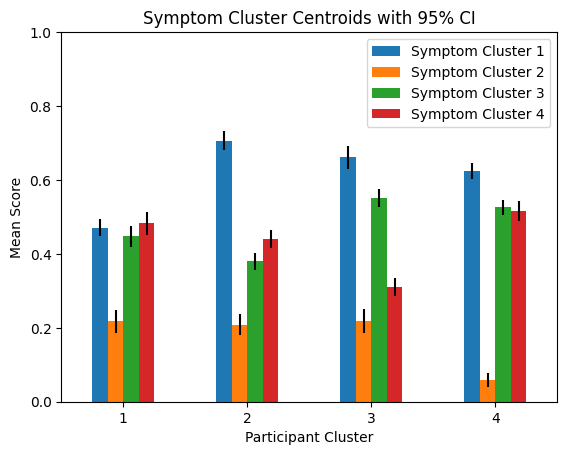

In [ ]:
# Raw Score 4 cluster

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# create dataframe CnC is the clustered bars and error bars
C1C = (0.4710, 0.7056, 0.6615, 0.6236)
C2C = (0.2173, 0.2086, 0.2184, 0.0583)
C3C = (0.4472, 0.3794, 0.5511, 0.526)
C4C = (0.4830, 0.4398, 0.3102, 0.5163)
index = ['1','2', '3', '4']
df = pd.DataFrame({'Symptom Cluster 1': C1C, 'Symptom Cluster 2': C2C, 'Symptom Cluster 3': C3C, 'Symptom Cluster 4': C4C,
                   'Cluster1_moe':   (0.0236,  0.0256, 0.0308, 0.0223),  # Margin Of Error
                   'Cluster2_moe': (0.0315, 0.0277, 0.0321, 0.0195),
                  'Cluster3_moe': (0.0282, 0.0232, 0.024, 0.0202),
                  'Cluster4_moe': (0.0306, 0.0237, 0.0238, 0.0262)},
                 index=index)

# plot
ax = df[['Symptom Cluster 1', 'Symptom Cluster 2', 'Symptom Cluster 3', 'Symptom Cluster 4']].plot.bar(rot=0)
plt.xlabel('Participant Cluster')
plt.ylabel('Mean Score')
plt.ylim(0, 1)
plt.title('Symptom Cluster Centroids with 95% CI')

# bar_moe[i] is bar/patch i's margin of error, i.e., half the length of an
# errorbar centered at the bar's height
bar_moe = np.ravel(df[['Cluster1_moe', 'Cluster2_moe', 'Cluster3_moe', 'Cluster4_moe']].values.T)
assert len(bar_moe) == len(ax.patches)

for patch, moe in zip(ax.patches, bar_moe):
    height = patch.get_height() # of bar
    min_y, max_y = height - moe, height + moe
    plt.vlines(patch.get_x() + patch.get_width()/2,
               min_y, max_y, color='k')

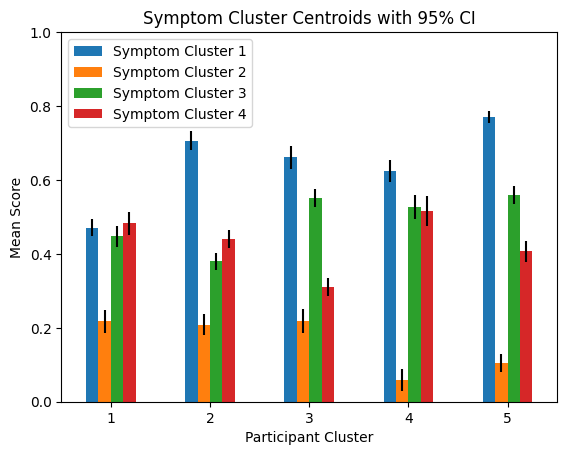

In [ ]:
# Raw Score 5 cluster

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# create dataframe CnC is the clustered bars and error bars
C1C = (0.4710, 0.7056, 0.6615, 0.6236, 0.7701)
C2C = (0.2173, 0.2086, 0.2184, 0.0583, 0.1052)
C3C = (0.4472, 0.3794, 0.5511, 0.5264, 0.5592)
C4C = (0.4830, 0.4398, 0.3102, 0.5163, 0.4071)
index = ['1','2', '3', '4', '5']
df = pd.DataFrame({'Symptom Cluster 1': C1C, 'Symptom Cluster 2': C2C, 'Symptom Cluster 3': C3C, 'Symptom Cluster 4': C4C,
                   'Cluster1_moe':   (0.0236,  0.0256, 0.0308, 0.0299, 0.0152),  # Margin Of Error
                   'Cluster2_moe': (0.0315, 0.0277, 0.0321, 0.0291, 0.0244),
                  'Cluster3_moe': (0.0282, 0.0232, 0.024, 0.0324, 0.0253),
                  'Cluster4_moe': (0.0306, 0.0237, 0.0238, 0.041, 0.0278)},
                 index=index)

# plot
ax = df[['Symptom Cluster 1', 'Symptom Cluster 2', 'Symptom Cluster 3', 'Symptom Cluster 4']].plot.bar(rot=0)
plt.xlabel('Participant Cluster')
plt.ylabel('Mean Score')
plt.ylim(0, 1)
plt.title('Symptom Cluster Centroids with 95% CI')

# bar_moe[i] is bar/patch i's margin of error, i.e., half the length of an
# errorbar centered at the bar's height
bar_moe = np.ravel(df[['Cluster1_moe', 'Cluster2_moe', 'Cluster3_moe', 'Cluster4_moe']].values.T)
assert len(bar_moe) == len(ax.patches)

for patch, moe in zip(ax.patches, bar_moe):
    height = patch.get_height() # of bar
    min_y, max_y = height - moe, height + moe
    plt.vlines(patch.get_x() + patch.get_width()/2,
               min_y, max_y, color='k')

Z Scores: 4 and 5 cluster models

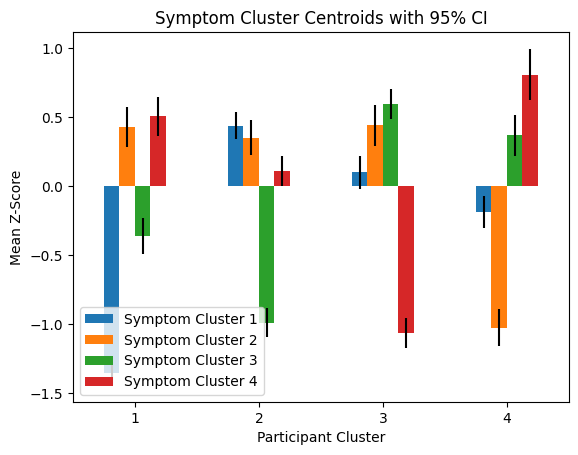

In [ ]:
# Z-SCORE 4 cluster

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# create dataframe CnC is the clustered bars and error bars
C1C = (-1.3507, 0.4374, 0.1011, -0.1876)
C2C = (0.4318, 0.3522, 0.4420, -1.0264)
C3C = (-0.3626, -0.9882, 0.5973, 0.3691)
C4C = (0.5064, 0.1130, -1.0661, 0.8093)
index = ['1','2', '3', '4']
df = pd.DataFrame({'Symptom Cluster 1': C1C, 'Symptom Cluster 2': C2C, 'Symptom Cluster 3': C3C, 'Symptom Cluster 4': C4C,
                   'Cluster1_moe':   (0.0898,  0.0977, 0.1174, 0.1139),  # Margin Of Error
                   'Cluster2_moe': (0.1446, 0.1272, 0.1473, 0.1337),
                  'Cluster3_moe': (0.1302, 0.1072, 0.1111, 0.1494),
                  'Cluster4_moe': (0.1394, 0.1079, 0.1086, 0.1866)},
                 index=index)

# plot
ax = df[['Symptom Cluster 1', 'Symptom Cluster 2', 'Symptom Cluster 3', 'Symptom Cluster 4']].plot.bar(rot=0)
plt.xlabel('Participant Cluster')
plt.ylabel('Mean Z-Score')
# plt.ylim(0, 1)
plt.title('Symptom Cluster Centroids with 95% CI')

# bar_moe[i] is bar/patch i's margin of error, i.e., half the length of an
# errorbar centered at the bar's height
bar_moe = np.ravel(df[['Cluster1_moe', 'Cluster2_moe', 'Cluster3_moe', 'Cluster4_moe']].values.T)
assert len(bar_moe) == len(ax.patches)

for patch, moe in zip(ax.patches, bar_moe):
    height = patch.get_height() # of bar
    min_y, max_y = height - moe, height + moe
    plt.vlines(patch.get_x() + patch.get_width()/2,
               min_y, max_y, color='k')

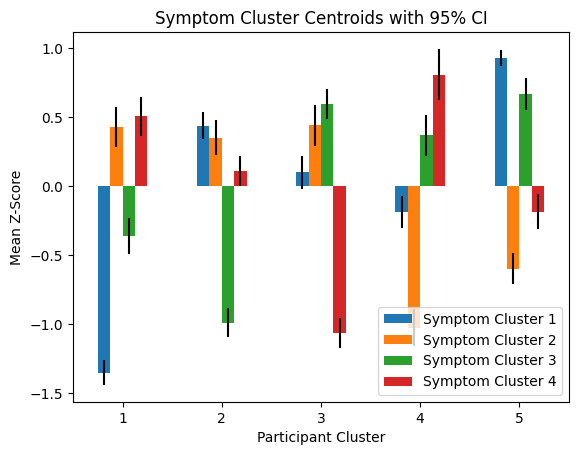

In [ ]:
# Z-SCORE 5 cluster

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# create dataframe CnC is the clustered bars and error bars
C1C = (-1.3507, 0.4374, 0.1011, -0.1876, 0.9287)
C2C = (0.4318, 0.3522, 0.4420, -1.0264, -0.5967)
C3C = (-0.3626, -0.9882, 0.5973, 0.3691, 0.6718)
C4C = (0.5064, 0.1130, -1.0661, 0.8093, -0.1843)
index = ['1','2', '3', '4', '5']
df = pd.DataFrame({'Symptom Cluster 1': C1C, 'Symptom Cluster 2': C2C, 'Symptom Cluster 3': C3C, 'Symptom Cluster 4': C4C,
                   'Cluster1_moe':   (0.0898,  0.0977, 0.1174, 0.1139, 0.0580),  # Margin Of Error
                   'Cluster2_moe': (0.1446, 0.1272, 0.1473, 0.1337, 0.1119),
                  'Cluster3_moe': (0.1302, 0.1072, 0.1111, 0.1494, 0.1168),
                  'Cluster4_moe': (0.1394, 0.1079, 0.1086, 0.1866, 0.1264)},
                 index=index)

# plot
ax = df[['Symptom Cluster 1', 'Symptom Cluster 2', 'Symptom Cluster 3', 'Symptom Cluster 4']].plot.bar(rot=0)
plt.xlabel('Participant Cluster')
plt.ylabel('Mean Z-Score')
# plt.ylim(0, 1)
plt.title('Symptom Cluster Centroids with 95% CI')

# bar_moe[i] is bar/patch i's margin of error, i.e., half the length of an
# errorbar centered at the bar's height
bar_moe = np.ravel(df[['Cluster1_moe', 'Cluster2_moe', 'Cluster3_moe', 'Cluster4_moe']].values.T)
assert len(bar_moe) == len(ax.patches)

for patch, moe in zip(ax.patches, bar_moe):
    height = patch.get_height() # of bar
    min_y, max_y = height - moe, height + moe
    plt.vlines(patch.get_x() + patch.get_width()/2,
               min_y, max_y, color='k')

Raw Score: 4 and 5 cluster models

TSS=0.49718

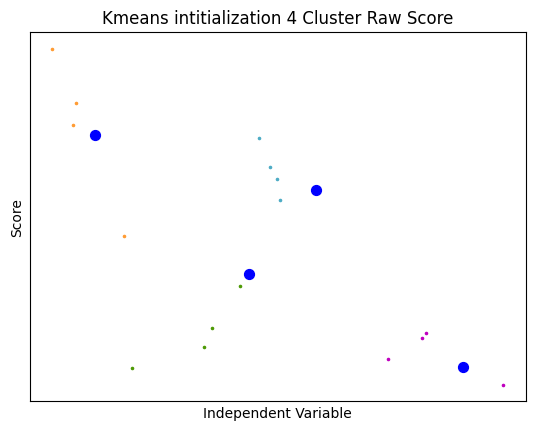

In [ ]:
import matplotlib.pyplot as plt

from sklearn.cluster import kmeans_plusplus
from sklearn.datasets import make_blobs

# Raw score
# Generating sample data
n_samples = 16
n_components = 4

X, y_true = make_blobs(
    n_samples=n_samples, centers=n_components, cluster_std=0.705109921, random_state=0
)
X = X[:, ::-1]

# Calculate seeds from k-means++
centers_init, indices = kmeans_plusplus(X, n_clusters=4, random_state=0)

# Plot init seeds along side sample data
plt.figure(1)
colors = ["#4EACC5", "#FF9C34", "#4E9A06", "m"]

for k, col in enumerate(colors):
    cluster_data = y_true == k
    plt.scatter(X[cluster_data, 0], X[cluster_data, 1], c=col, marker=".", s=10)

plt.scatter(centers_init[:, 0], centers_init[:, 1], c="b", s=50)
plt.title("Kmeans intitialization 4 Cluster Raw Score")
plt.xlabel('Independent Variable')
plt.ylabel('Score')
plt.xticks([])
plt.yticks([])
plt.show()

TSS=0.73563

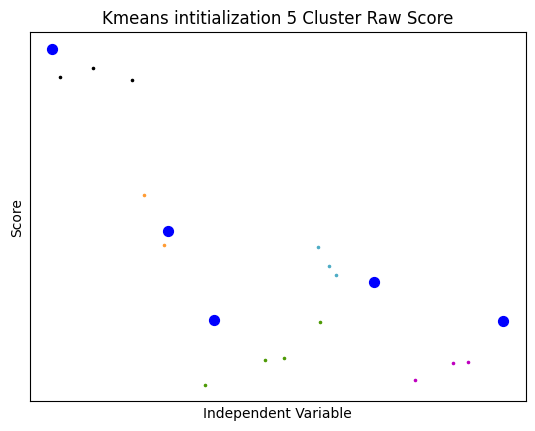

In [ ]:
import matplotlib.pyplot as plt

from sklearn.cluster import kmeans_plusplus
from sklearn.datasets import make_blobs

# Raw score
# Generating sample data
n_samples = 20
n_components = 5

X, y_true = make_blobs(
    n_samples=n_samples, centers=n_components, cluster_std=0.857688755, random_state=0
)
X = X[:, ::-1]

# Calculate seeds from k-means++
centers_init, indices = kmeans_plusplus(X, n_clusters=5, random_state=0)

# Plot init seeds along side sample data
plt.figure(1)
colors = ["#4EACC5", "#FF9C34", "#4E9A06", "m", "k"]

for k, col in enumerate(colors):
    cluster_data = y_true == k
    plt.scatter(X[cluster_data, 0], X[cluster_data, 1], c=col, marker=".", s=10)

plt.scatter(centers_init[:, 0], centers_init[:, 1], c="b", s=50)
plt.title("Kmeans intitialization 5 Cluster Raw Score")
plt.xlabel('Independent Variable')
plt.ylabel('Score')
plt.xticks([])
plt.yticks([])
plt.show()

Z Score: 4 and 5 cluster models

TSS=7.240017

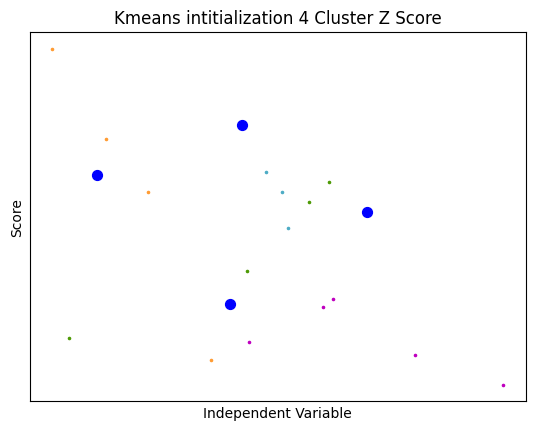

In [ ]:
import matplotlib.pyplot as plt

from sklearn.cluster import kmeans_plusplus
from sklearn.datasets import make_blobs

# Z score
# Generating sample data
n_samples = 16
n_components = 4

X, y_true = make_blobs(
    n_samples=n_samples, centers=n_components, cluster_std=2.690727968, random_state=0
)
X = X[:, ::-1]

# Calculate seeds from k-means++
centers_init, indices = kmeans_plusplus(X, n_clusters=4, random_state=0)

# Plot init seeds along side sample data
plt.figure(1)
colors = ["#4EACC5", "#FF9C34", "#4E9A06", "m"]

for k, col in enumerate(colors):
    cluster_data = y_true == k
    plt.scatter(X[cluster_data, 0], X[cluster_data, 1], c=col, marker=".", s=10)

plt.scatter(centers_init[:, 0], centers_init[:, 1], c="b", s=50)
plt.title("Kmeans intitialization 4 Cluster Z Score")
plt.xlabel('Independent Variable')
plt.ylabel('Score')
plt.xticks([])
plt.yticks([])
plt.show()

TSS=8.986063

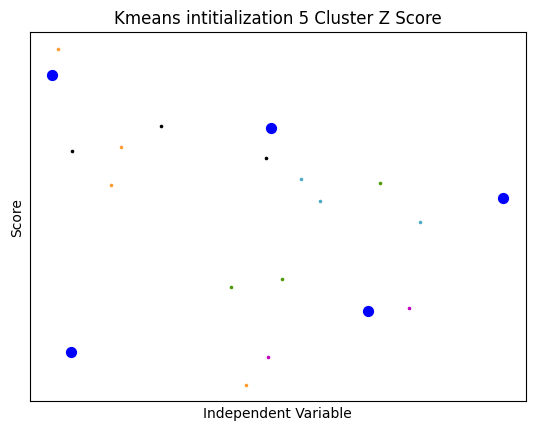

In [ ]:
import matplotlib.pyplot as plt

from sklearn.cluster import kmeans_plusplus
from sklearn.datasets import make_blobs

# Z score
# Generating sample data
n_samples = 20
n_components = 5

X, y_true = make_blobs(
    n_samples=n_samples, centers=n_components, cluster_std=2.997676267, random_state=0
)
X = X[:, ::-1]

# Calculate seeds from k-means++
centers_init, indices = kmeans_plusplus(X, n_clusters=5, random_state=0)

# Plot init seeds along side sample data
plt.figure(1)
colors = ["#4EACC5", "#FF9C34", "#4E9A06", "m", "k"]

for k, col in enumerate(colors):
    cluster_data = y_true == k
    plt.scatter(X[cluster_data, 0], X[cluster_data, 1], c=col, marker=".", s=10)

plt.scatter(centers_init[:, 0], centers_init[:, 1], c="b", s=50)
plt.title("Kmeans intitialization 5 Cluster Z Score")
plt.xlabel('Independent Variable')
plt.ylabel('Score')
plt.xticks([])
plt.yticks([])
plt.show()

In [ ]:
import statsmodels.api as sm

from scipy.stats import t, ttest_ind, probplot
from IPython.display import display

pd.set_option('display.float_format', '{:.2f}'.format)


def calc_coef_pvalues(X, df, clusters, fits, qqplot=False):
  nclusters = max(clusters)

  ssri_mask = df['DRUG'].apply(categorize_by_class) == 0
  snri_mask = df['DRUG'].apply(categorize_by_class) == 1

  rows = []
  columns = pd.DataFrame([['#', 'SSRI', ''],
                          ['#', 'SNRI', ''],
                          # ['t-Test P>|t|', '', ''],
                          # ["Cohen's d", '', ''],
                          ['OLS R^2', 'SSRI', ''],
                          ['OLS R^2', 'SNRI', ''],
                          # ['OLS Coef. P>|t|', 'SSRI', 'β1'],
                          # ['OLS Coef. P>|t|', 'SSRI', 'β2'],
                          # ['OLS Coef. P>|t|', 'SSRI', 'β3'],
                          # ['OLS Coef. P>|t|', 'SSRI', 'β4'],
                          # ['OLS Coef. P>|t|', 'SNRI', 'β1'],
                          # ['OLS Coef. P>|t|', 'SNRI', 'β2'],
                          # ['OLS Coef. P>|t|', 'SNRI', 'β3'],
                          # ['OLS Coef. P>|t|', 'SNRI', 'β4'],
                          ['OLS Coef. P>|t|', 'SSRI - SNRI', 'const'],
                          ['OLS Coef. P>|t|', 'SSRI - SNRI', 'β1'],
                          ['OLS Coef. P>|t|', 'SSRI - SNRI', 'β2'],
                          ['OLS Coef. P>|t|', 'SSRI - SNRI', 'β3'],
                          ['OLS Coef. P>|t|', 'SSRI - SNRI', 'β4'],
                          ['OLS Coef.', 'SSRI', 'const'],
                          ['OLS Coef.', 'SSRI', 'β1'],
                          ['OLS Coef.', 'SSRI', 'β2'],
                          ['OLS Coef.', 'SSRI', 'β3'],
                          ['OLS Coef.', 'SSRI', 'β4'],
                          ['OLS Coef.', 'SNRI', 'const'],
                          ['OLS Coef.', 'SNRI', 'β1'],
                          ['OLS Coef.', 'SNRI', 'β2'],
                          ['OLS Coef.', 'SNRI', 'β3'],
                          ['OLS Coef.', 'SNRI', 'β4'],
                          # ['OLS Coef.', 'SSRI - SNRI', 'const'],
                          # ['OLS Coef.', 'SSRI - SNRI', 'β1'],
                          # ['OLS Coef.', 'SSRI - SNRI', 'β2'],
                          # ['OLS Coef.', 'SSRI - SNRI', 'β3'],
                          # ['OLS Coef.', 'SSRI - SNRI', 'β4']
                          ],
                          columns=['Cluster', '', ''])

  for n in range(1, nclusters + 1):
    ssri_dist = df.loc[(clusters == n) & ssri_mask, 'DHAMD_norm']
    snri_dist = df.loc[(clusters == n) & snri_mask, 'DHAMD_norm']

    ssri_size = ssri_dist.size
    snri_size = snri_dist.size

    if qqplot:
      fig, axs = plt.subplots(nrows=1, ncols=2, layout='constrained', sharex=True, sharey=True)
      fig.suptitle('QQ Plot')
      fig.supxlabel('Ordered Values')
      fig.supxlabel('Theoretical Quantiles')

      probplot(ssri_dist, dist='norm', plot=axs[0])
      axs[0].set_title('SSRI')
      axs[0].set_xlabel('')
      axs[0].set_ylabel('')

      probplot(snri_dist, dist='norm', plot=axs[1])
      axs[1].set_title('SNRI')
      axs[1].set_xlabel('')
      axs[1].set_ylabel('')

      plt.show()

    # conduct t-test
    _, ttest_p_val = ttest_ind(ssri_dist, snri_dist)

    # calculate cohen's d and 95% confidence interval
    dof = ssri_size + snri_size - 2

    mean_diff = ssri_dist.mean() - snri_dist.mean()
    std_pooled = np.sqrt(((ssri_size - 1) * ssri_dist.var() + (snri_size - 1) * snri_dist.var()) / dof)
    cohens_d = mean_diff / std_pooled

    t_crit = t.ppf(0.975, dof)  # two-tailed
    std_err = np.sqrt((ssri_size + snri_size) / (ssri_size * snri_size) + cohens_d ** 2 / (2 * (ssri_size + snri_size)))

    lower_bound = cohens_d - t_crit * std_err
    upper_bound = cohens_d + t_crit * std_err

    fit_ssri = fits[n]['SSRI']
    fit_snri = fits[n]['SNRI']

    # calculate p-values
    pvalues = []
    for i in ['const', 'amean_0', 'amean_1', 'amean_2', 'amean_3']:
      if i in fit_ssri.params.index and i in fit_snri.params.index:
        t_stat = (fit_ssri.params.loc[i] - fit_snri.params.loc[i]) / np.sqrt(fit_ssri.bse.loc[i] ** 2 + fit_snri.bse.loc[i] ** 2)
        dof = min(ssri_size, snri_size) - 1
        pvalue = 2 * (1 - t.cdf(abs(t_stat), dof))
        pvalues.append(pvalue)
      else:
        pvalues.append(np.nan)

    rows.append([
      ssri_size,
      snri_size,
      # ttest_p_val,
      # f'{cohens_d:.2f} [{lower_bound:.2f}, {upper_bound:.2f}]',
      fit_ssri.rsquared,
      fit_snri.rsquared,
      # fit_ssri.pvalues.loc['amean_0'],
      # fit_ssri.pvalues.loc['amean_1'],
      # fit_ssri.pvalues.loc['amean_2'],
      # fit_ssri.pvalues.loc['amean_3'],
      # fit_snri.pvalues.loc['amean_0'],
      # fit_snri.pvalues.loc['amean_1'],
      # fit_snri.pvalues.loc['amean_2'],
      # fit_snri.pvalues.loc['amean_3'],
      *pvalues,
      fit_ssri.params.loc['const'] if 'const' in fit_ssri.params.index else np.nan,
      fit_ssri.params.loc['amean_0'],
      fit_ssri.params.loc['amean_1'],
      fit_ssri.params.loc['amean_2'],
      fit_ssri.params.loc['amean_3'],
      fit_snri.params.loc['const'] if 'const' in fit_snri.params.index else np.nan,
      fit_snri.params.loc['amean_0'],
      fit_snri.params.loc['amean_1'],
      fit_snri.params.loc['amean_2'],
      fit_snri.params.loc['amean_3'],
      # fit_ssri.params.loc['const'] - fit_snri.params.loc['const'],
      # fit_ssri.params.loc['amean_0'] - fit_snri.params.loc['amean_0'],
      # fit_ssri.params.loc['amean_1'] - fit_snri.params.loc['amean_1'],
      # fit_ssri.params.loc['amean_2'] - fit_snri.params.loc['amean_2'],
      # fit_ssri.params.loc['amean_3'] - fit_snri.params.loc['amean_3']
    ])

    for i in range(4, 9):
      if rows[-1][i] < 0.05:
        rows[-1][i] = f'{rows[-1][i]:.2f}*'

  display(pd.DataFrame(rows, columns=pd.MultiIndex.from_frame(columns), index=range(1, nclusters + 1)))

In [ ]:
calc_coef_pvalues(X_mod, df_mod_filtered, clusters_mod_1, fits_1)

Cluster    #      OLS R^2      OLS Coef. P>|t|                     OLS Coef.                                              
        SSRI SNRI    SSRI SNRI     SSRI - SNRI                          SSRI                      SNRI                    
                                         const   β1   β2   β3   β4     const   β1   β2   β3   β4 const   β1   β2   β3   β4
1        160  572    0.09 0.08            0.09 0.40 0.85 0.71 0.72     -2.36 2.14 3.74 3.54 3.57  0.63 1.06 3.43 2.97 2.96

In [ ]:
calc_coef_pvalues(X_mod, df_mod_filtered, clusters_mod_3, fits_3)

Cluster    #      OLS R^2      OLS Coef. P>|t|                       OLS Coef.                                                 
        SSRI SNRI    SSRI SNRI     SSRI - SNRI                            SSRI                        SNRI                     
                                         const     β1   β2   β3   β4     const    β1   β2   β3    β4 const    β1   β2   β3   β4
1         46  122    0.28 0.15           0.03*  0.01* 0.70 0.67 0.68     -5.88  9.00 5.67 3.39  3.15  1.86 -1.25 4.36 1.97 4.54
2         47  122    0.11 0.05            0.37   0.64 0.95 0.66 0.34      2.17 -0.07 1.97 4.04 -1.40 -1.51  1.82 1.73 5.81 2.72
3         67  328    0.16 0.09            0.44   0.62 0.99 0.92 0.32     -1.23  0.04 3.90 2.00  5.34  1.21  1.33 3.87 1.70 2.90

In [ ]:
calc_coef_pvalues(X_mod, df_mod_filtered, clusters_mod_5, fits_5)

Cluster    #      OLS R^2      OLS Coef. P>|t|                       OLS Coef.                                                    
        SSRI SNRI    SSRI SNRI     SSRI - SNRI                            SSRI                         SNRI                       
                                         const     β1   β2   β3   β4     const    β1    β2   β3    β4 const    β1    β2    β3   β4
1         46  122    0.28 0.15           0.03*  0.01* 0.70 0.67 0.68     -5.88  9.00  5.67 3.39  3.15  1.86 -1.25  4.36  1.97 4.54
2         47  122    0.11 0.05            0.37   0.64 0.95 0.66 0.34      2.17 -0.07  1.97 4.04 -1.40 -1.51  1.82  1.73  5.81 2.72
3         22  115    0.35 0.15            0.96   0.39 0.97 0.87 0.47      0.53 -3.93  4.93 0.65 10.72  0.24  0.48  5.17  1.70 6.31
4         19   71    0.55 0.21            0.74   0.19 0.29 0.31 0.29     -0.45 -3.73 15.81 5.18  6.42  1.49  5.35  7.83 -1.19 0.59
5         26  142    0.08 0.06            1.00   0.76 0.74 0.92 0.59      0.40  4.63  1.87 1.96 -0.99  0.47  1.15 -0.99  2.62 4.33

In [ ]:
calc_coef_pvalues(X_mod, df_mod_filtered, clusters_mod_7, fits_7)

Cluster    #      OLS R^2      OLS Coef. P>|t|                           OLS Coef.                                                     
        SSRI SNRI    SSRI SNRI     SSRI - SNRI                                SSRI                           SNRI                      
                                         const   β1     β2     β3     β4     const     β1    β2    β3    β4 const   β1    β2    β3   β4
1         16   30    0.53 0.25            0.20 0.26   0.25   0.46   0.80    -13.23  13.92 10.99  5.48 12.05 -0.29 2.45 -2.82 -0.39 9.28
2         30   92    0.24 0.23            0.15 0.21   0.74   0.75   0.79     -6.70   8.34  5.03  4.52  3.58  1.20 0.54  3.32  2.71 4.82
3         47  122    0.11 0.05            0.37 0.64   0.95   0.66   0.34      2.17  -0.07  1.97  4.04 -1.40 -1.51 1.82  1.73  5.81 2.72
4         22  115    0.35 0.15            0.96 0.39   0.97   0.87   0.47      0.53  -3.93  4.93  0.65 10.72  0.24 0.48  5.17  1.70 6.31
5         19   71    0.55 0.21            0.74 0.19   0.29   0.31   0.29     -0.45  -3.73 15.81  5.18  6.42  1.49 5.35  7.83 -1.19 0.59
6         11   56    0.31 0.05             NaN 0.50   0.60   0.51   0.87       NaN -18.46  9.02 21.35 -4.08   NaN 9.07 -0.85 -3.09 1.47
7         15   86    0.88 0.07            0.40 0.60  0.03*  0.04*  0.01*     -7.14  -0.38 11.56 12.69 20.81 -1.36 3.29 -4.77  3.01 4.10

# Task 5

# Task 6

In [ ]:
from scipy.stats import t
from math import sqrt


def print_cluster_centroids(group):
  print(f'Symptom Cluster {group.name} Centroid:')
  n = len(group.index)
  tscore = t.ppf(1 - 0.025, n - 1)  # 95% confidence interval
  for i in range(nclusters_mod):
    mean = group[f'amean_{i}'].mean()
    std = group[f'amean_{i}'].std()
    print(f'Participant Cluster {i}: {mean:.4f} with 95% CI [{mean - tscore * std / sqrt(n):.4f}, {mean + tscore * std / sqrt(n):.4f}]')
  print()


def plot_cluster_centroids(X, clusters):
  nclusters = max(clusters)

  plt.figure(figsize=(5 + nclusters * 0.5, 5))
  copy = X.copy()
  copy.rename(columns={'amean_0': 'Participant\nCluster 1\nScore', 'amean_1': 'Participant\nCluster 2\nScore', 'amean_2': 'Participant\nCluster 3\nScore', 'amean_3': 'Participant\nCluster 4\nScore'}, inplace=True)
  copy['Symptom Cluster'] = clusters
  sns.barplot(copy.melt(id_vars=['Symptom Cluster']), x='variable', y='value', hue='Symptom Cluster', estimator='mean', errorbar=('ci', 95), palette='pastel')
  plt.title('Symptom Cluster Centroids with 95% CI')
  plt.xlabel('')
  plt.ylabel('')
  plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
  legend = plt.gca().get_legend()
  for i, text in enumerate(legend.texts):
    text.set_text(f'{i + 1}')
  plt.show()
  copy.rename(columns={'Participant\nCluster 1\nScore': 'amean_0', 'Participant\nCluster 2\nScore': 'amean_1', 'Participant\nCluster 3\nScore': 'amean_2', 'Participant\nCluster 4\nScore': 'amean_3'}, inplace=True)

  copy.groupby('Symptom Cluster').apply(print_cluster_centroids)

  copy.apply(zscore, axis=0).groupby('Symptom Cluster').apply(print_cluster_centroids)

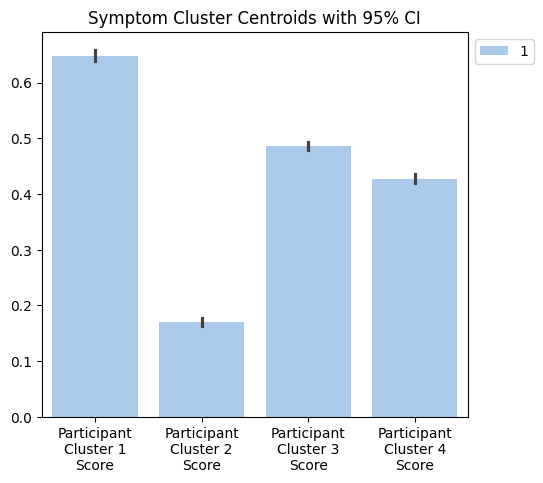

Symptom Cluster 1 Centroid:
Participant Cluster 0: 0.6482 with 95% CI [0.6387, 0.6578]
Participant Cluster 1: 0.1702 with 95% CI [0.1623, 0.1781]
Participant Cluster 2: 0.4864 with 95% CI [0.4786, 0.4943]
Participant Cluster 3: 0.4274 with 95% CI [0.4194, 0.4353]



In [ ]:
plot_cluster_centroids(X_mod, clusters_mod_1)

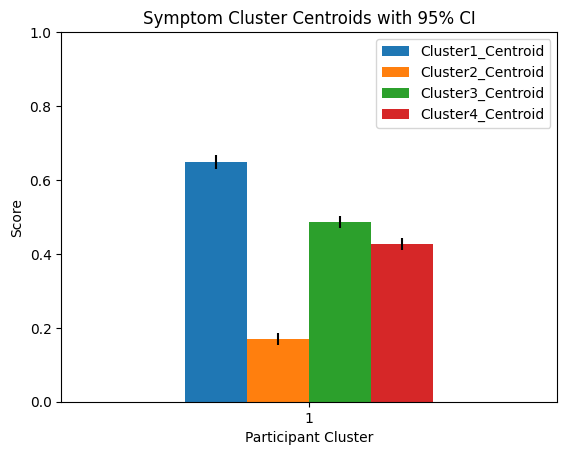

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# create dataframe CnC is the clustered bars
C1C = (0.6482)
C2C = (0.1702)
C3C = (0.4864)
C4C = (0.4274)
index = ['1']
df = pd.DataFrame({'Cluster1_Centroid': C1C, 'Cluster2_Centroid': C2C, 'Cluster3_Centroid': C3C, 'Cluster4_Centroid': C4C,
                   'Cluster1_moe':   (0.0191),  # Margin Of Error ie: Error bars
                   'Cluster2_moe': (0.0158),
                  'Cluster3_moe': (0.0157),
                  'Cluster4_moe': (0.0159)},
                 index=index)

# plot
ax = df[['Cluster1_Centroid', 'Cluster2_Centroid', 'Cluster3_Centroid', 'Cluster4_Centroid']].plot.bar(rot=0)
plt.xlabel('Participant Cluster')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.title('Symptom Cluster Centroids with 95% CI')

# bar_moe[i] is bar/patch i's margin of error, i.e., half the length of an
# errorbar centered at the bar's height
bar_moe = np.ravel(df[['Cluster1_moe', 'Cluster2_moe', 'Cluster3_moe', 'Cluster4_moe']].values.T)
assert len(bar_moe) == len(ax.patches)

for patch, moe in zip(ax.patches, bar_moe):
    height = patch.get_height() # of bar
    min_y, max_y = height - moe, height + moe
    plt.vlines(patch.get_x() + patch.get_width()/2,
               min_y, max_y, color='k')

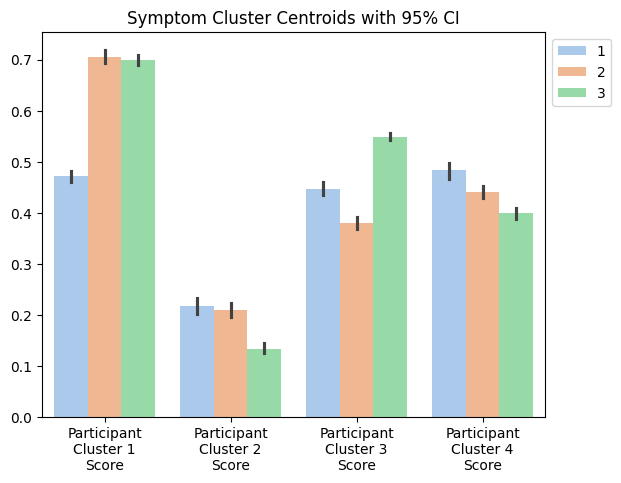

Symptom Cluster 1 Centroid:
Participant Cluster 0: 0.4710 with 95% CI [0.4592, 0.4828]
Participant Cluster 1: 0.2173 with 95% CI [0.2015, 0.2330]
Participant Cluster 2: 0.4472 with 95% CI [0.4331, 0.4613]
Participant Cluster 3: 0.4830 with 95% CI [0.4677, 0.4983]

Symptom Cluster 2 Centroid:
Participant Cluster 0: 0.7056 with 95% CI [0.6928, 0.7184]
Participant Cluster 1: 0.2086 with 95% CI [0.1947, 0.2224]
Participant Cluster 2: 0.3794 with 95% CI [0.3678, 0.3910]
Participant Cluster 3: 0.4398 with 95% CI [0.4279, 0.4516]

Symptom Cluster 3 Centroid:
Participant Cluster 0: 0.6991 with 95% CI [0.6897, 0.7084]
Participant Cluster 1: 0.1338 with 95% CI [0.1233, 0.1442]
Participant Cluster 2: 0.5489 with 95% CI [0.5411, 0.5567]
Participant Cluster 3: 0.3984 with 95% CI [0.3870, 0.4098]



In [ ]:
plot_cluster_centroids(X_mod, clusters_mod_3)

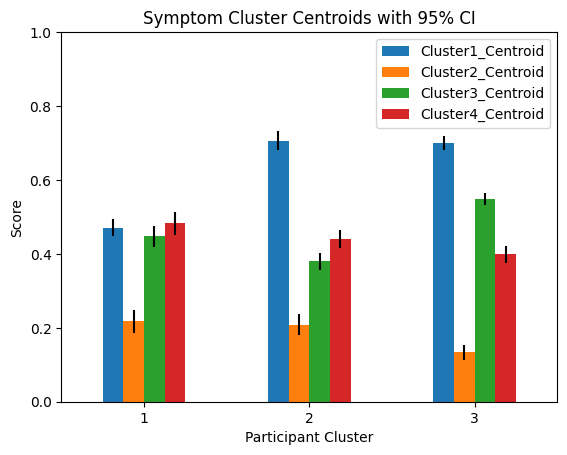

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# create dataframe CnC is the clustered bars and error bars
C1C = (0.4710, 0.7056, 0.6991)
C2C = (0.2173, 0.2086, 0.1338)
C3C = (0.4472, 0.3794, 0.5489)
C4C = (0.4830, 0.4398, 0.3984)
index = ['1','2', '3']
df = pd.DataFrame({'Cluster1_Centroid': C1C, 'Cluster2_Centroid': C2C, 'Cluster3_Centroid': C3C, 'Cluster4_Centroid': C4C,
                   'Cluster1_moe':   (0.0236,  0.0256, 0.0187),  # Margin Of Error
                   'Cluster2_moe': (0.0315, 0.0277, 0.0209),
                  'Cluster3_moe': (0.0282, 0.0232, 0.0156),
                  'Cluster4_moe': (0.0306, 0.0237, 0.0228)},
                 index=index)

# plot
ax = df[['Cluster1_Centroid', 'Cluster2_Centroid', 'Cluster3_Centroid', 'Cluster4_Centroid']].plot.bar(rot=0)
plt.xlabel('Participant Cluster')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.title('Symptom Cluster Centroids with 95% CI')

# bar_moe[i] is bar/patch i's margin of error, i.e., half the length of an
# errorbar centered at the bar's height
bar_moe = np.ravel(df[['Cluster1_moe', 'Cluster2_moe', 'Cluster3_moe', 'Cluster4_moe']].values.T)
assert len(bar_moe) == len(ax.patches)

for patch, moe in zip(ax.patches, bar_moe):
    height = patch.get_height() # of bar
    min_y, max_y = height - moe, height + moe
    plt.vlines(patch.get_x() + patch.get_width()/2,
               min_y, max_y, color='k')

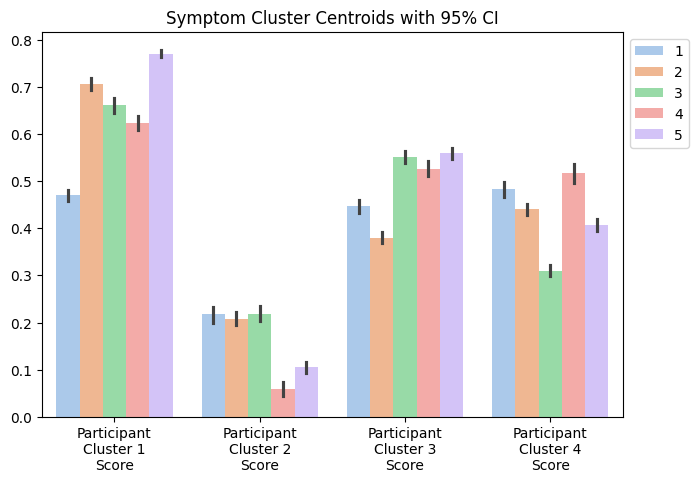

Symptom Cluster 1 Centroid:
Participant Cluster 0: 0.4710 with 95% CI [0.4592, 0.4828]
Participant Cluster 1: 0.2173 with 95% CI [0.2015, 0.2330]
Participant Cluster 2: 0.4472 with 95% CI [0.4331, 0.4613]
Participant Cluster 3: 0.4830 with 95% CI [0.4677, 0.4983]

Symptom Cluster 2 Centroid:
Participant Cluster 0: 0.7056 with 95% CI [0.6928, 0.7184]
Participant Cluster 1: 0.2086 with 95% CI [0.1947, 0.2224]
Participant Cluster 2: 0.3794 with 95% CI [0.3678, 0.3910]
Participant Cluster 3: 0.4398 with 95% CI [0.4279, 0.4516]

Symptom Cluster 3 Centroid:
Participant Cluster 0: 0.6615 with 95% CI [0.6461, 0.6769]
Participant Cluster 1: 0.2184 with 95% CI [0.2023, 0.2344]
Participant Cluster 2: 0.5511 with 95% CI [0.5391, 0.5631]
Participant Cluster 3: 0.3102 with 95% CI [0.2983, 0.3221]

Symptom Cluster 4 Centroid:
Participant Cluster 0: 0.6236 with 95% CI [0.6087, 0.6386]
Participant Cluster 1: 0.0583 with 95% CI [0.0438, 0.0729]
Participant Cluster 2: 0.5264 with 95% CI [0.5102, 0.5426]


In [ ]:
plot_cluster_centroids(X_mod, clusters_mod_5)

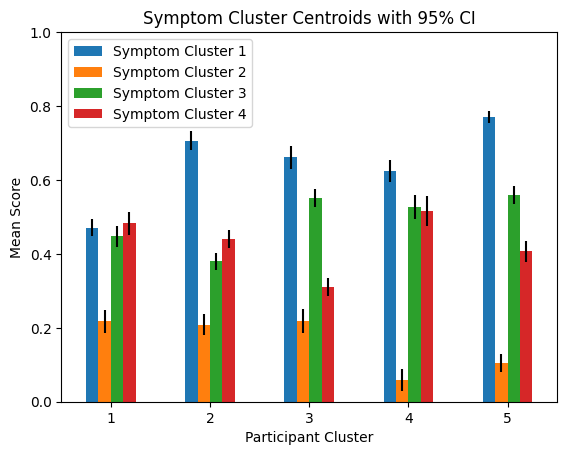

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# create dataframe CnC is the clustered bars and error bars
C1C = (0.4710, 0.7056, 0.6615, 0.6236, 0.7701)
C2C = (0.2173, 0.2086, 0.2184, 0.0583, 0.1052)
C3C = (0.4472, 0.3794, 0.5511, 0.5264, 0.5592)
C4C = (0.4830, 0.4398, 0.3102, 0.5163, 0.4071)
index = ['1','2', '3', '4', '5']
df = pd.DataFrame({'Symptom Cluster 1': C1C, 'Symptom Cluster 2': C2C, 'Symptom Cluster 3': C3C, 'Symptom Cluster 4': C4C,
                   'Cluster1_moe':   (0.0236,  0.0256, 0.0308, 0.0299, 0.0152),  # Margin Of Error
                   'Cluster2_moe': (0.0315, 0.0277, 0.0321, 0.0291, 0.0244),
                  'Cluster3_moe': (0.0282, 0.0232, 0.024, 0.0324, 0.0253),
                  'Cluster4_moe': (0.0306, 0.0237, 0.0238, 0.041, 0.0278)},
                 index=index)

# plot
ax = df[['Symptom Cluster 1', 'Symptom Cluster 2', 'Symptom Cluster 3', 'Symptom Cluster 4']].plot.bar(rot=0)
plt.xlabel('Participant Cluster')
plt.ylabel('Mean Score')
plt.ylim(0, 1)
plt.title('Symptom Cluster Centroids with 95% CI')

# bar_moe[i] is bar/patch i's margin of error, i.e., half the length of an
# errorbar centered at the bar's height
bar_moe = np.ravel(df[['Cluster1_moe', 'Cluster2_moe', 'Cluster3_moe', 'Cluster4_moe']].values.T)
assert len(bar_moe) == len(ax.patches)

for patch, moe in zip(ax.patches, bar_moe):
    height = patch.get_height() # of bar
    min_y, max_y = height - moe, height + moe
    plt.vlines(patch.get_x() + patch.get_width()/2,
               min_y, max_y, color='k')

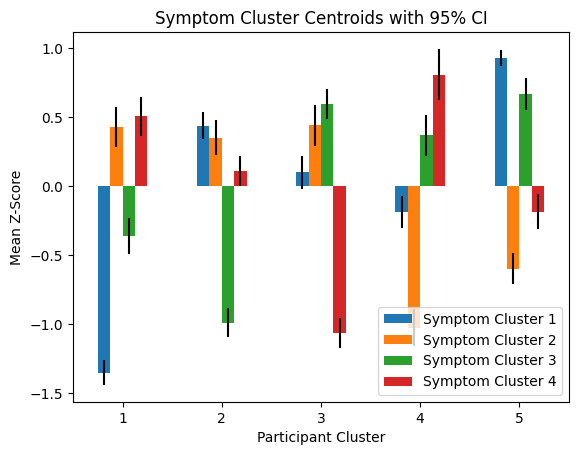

In [ ]:
# Z-SCORE

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# create dataframe CnC is the clustered bars and error bars
C1C = (-1.3507, 0.4374, 0.1011, -0.1876, 0.9287)
C2C = (0.4318, 0.3522, 0.4420, -1.0264, -0.5967)
C3C = (-0.3626, -0.9882, 0.5973, 0.3691, 0.6718)
C4C = (0.5064, 0.1130, -1.0661, 0.8093, -0.1843)
index = ['1','2', '3', '4', '5']
df = pd.DataFrame({'Symptom Cluster 1': C1C, 'Symptom Cluster 2': C2C, 'Symptom Cluster 3': C3C, 'Symptom Cluster 4': C4C,
                   'Cluster1_moe':   (0.0898,  0.0977, 0.1174, 0.1139, 0.0580),  # Margin Of Error
                   'Cluster2_moe': (0.1446, 0.1272, 0.1473, 0.1337, 0.1119),
                  'Cluster3_moe': (0.1302, 0.1072, 0.1111, 0.1494, 0.1168),
                  'Cluster4_moe': (0.1394, 0.1079, 0.1086, 0.1866, 0.1264)},
                 index=index)

# plot
ax = df[['Symptom Cluster 1', 'Symptom Cluster 2', 'Symptom Cluster 3', 'Symptom Cluster 4']].plot.bar(rot=0)
plt.xlabel('Participant Cluster')
plt.ylabel('Mean Z-Score')
# plt.ylim(0, 1)
plt.title('Symptom Cluster Centroids with 95% CI')

# bar_moe[i] is bar/patch i's margin of error, i.e., half the length of an
# errorbar centered at the bar's height
bar_moe = np.ravel(df[['Cluster1_moe', 'Cluster2_moe', 'Cluster3_moe', 'Cluster4_moe']].values.T)
assert len(bar_moe) == len(ax.patches)

for patch, moe in zip(ax.patches, bar_moe):
    height = patch.get_height() # of bar
    min_y, max_y = height - moe, height + moe
    plt.vlines(patch.get_x() + patch.get_width()/2,
               min_y, max_y, color='k')

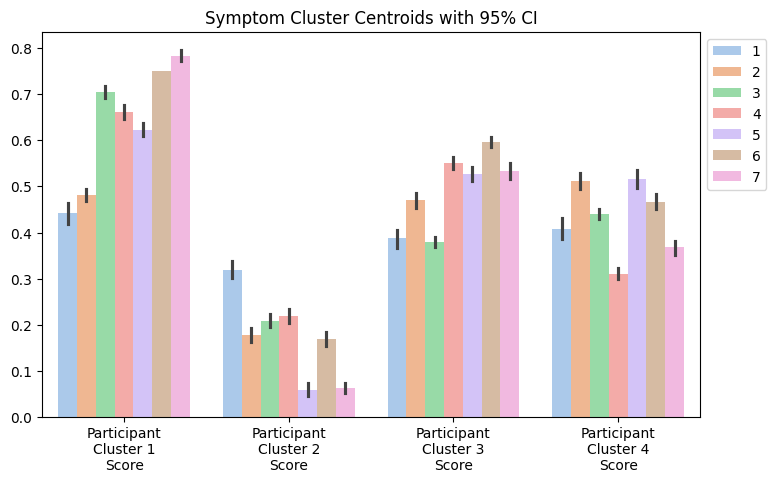

Symptom Cluster 1 Centroid:
Participant Cluster 0: 0.4429 with 95% CI [0.4186, 0.4673]
Participant Cluster 1: 0.3197 with 95% CI [0.3011, 0.3384]
Participant Cluster 2: 0.3872 with 95% CI [0.3652, 0.4092]
Participant Cluster 3: 0.4068 with 95% CI [0.3825, 0.4312]

Symptom Cluster 2 Centroid:
Participant Cluster 0: 0.4816 with 95% CI [0.4685, 0.4947]
Participant Cluster 1: 0.1786 with 95% CI [0.1628, 0.1945]
Participant Cluster 2: 0.4698 with 95% CI [0.4539, 0.4857]
Participant Cluster 3: 0.5117 with 95% CI [0.4953, 0.5282]

Symptom Cluster 3 Centroid:
Participant Cluster 0: 0.7056 with 95% CI [0.6928, 0.7184]
Participant Cluster 1: 0.2086 with 95% CI [0.1947, 0.2224]
Participant Cluster 2: 0.3794 with 95% CI [0.3678, 0.3910]
Participant Cluster 3: 0.4398 with 95% CI [0.4279, 0.4516]

Symptom Cluster 4 Centroid:
Participant Cluster 0: 0.6615 with 95% CI [0.6461, 0.6769]
Participant Cluster 1: 0.2184 with 95% CI [0.2023, 0.2344]
Participant Cluster 2: 0.5511 with 95% CI [0.5391, 0.5631]


In [ ]:
plot_cluster_centroids(X_mod, clusters_mod_7)

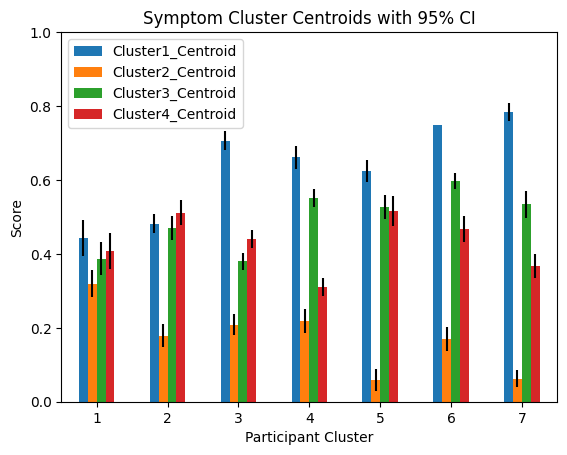

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# create dataframe CnC is the clustered bars and error bars
C1C = (0.4429, 0.4816, 0.7056, 0.6615, 0.6236, 0.7500, 0.7834)
C2C = (0.3197, 0.1786, 0.2086, 0.2184, 0.0583, 0.1698, 0.0623)
C3C = (0.3872, 0.4698, 0.3794, 0.5511, 0.5264, 0.5970, 0.5340)
C4C = (0.4068, 0.5117, 0.4398, 0.3102, 0.5163, 0.4664, 0.3678)
index = ['1','2', '3', '4', '5', '6', '7']
df = pd.DataFrame({'Cluster1_Centroid': C1C, 'Cluster2_Centroid': C2C, 'Cluster3_Centroid': C3C, 'Cluster4_Centroid': C4C,
                   'Cluster1_moe':   (0.0487,  0.0262, 0.0256, 0.0308, 0.0299, 0.00, 0.024),  # Margin Of Error
                   'Cluster2_moe': (0.0373, 0.0317, 0.0277, 0.0321, 0.0291, 0.0315, 0.0228),
                  'Cluster3_moe': (0.044, 0.0318, 0.0232, 0.024, 0.0324, 0.022, 0.0365),
                  'Cluster4_moe': (0.0487, 0.0329, 0.0237, 0.0238, 0.041, 0.0351, 0.0319)},
                 index=index)

# plot
ax = df[['Cluster1_Centroid', 'Cluster2_Centroid', 'Cluster3_Centroid', 'Cluster4_Centroid']].plot.bar(rot=0)
plt.xlabel('Participant Cluster')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.title('Symptom Cluster Centroids with 95% CI')

# bar_moe[i] is bar/patch i's margin of error, i.e., half the length of an
# errorbar centered at the bar's height
bar_moe = np.ravel(df[['Cluster1_moe', 'Cluster2_moe', 'Cluster3_moe', 'Cluster4_moe']].values.T)
assert len(bar_moe) == len(ax.patches)

for patch, moe in zip(ax.patches, bar_moe):
    height = patch.get_height() # of bar
    min_y, max_y = height - moe, height + moe
    plt.vlines(patch.get_x() + patch.get_width()/2,
               min_y, max_y, color='k')